# Blasting Sound Signal Analysis
## IAESTE Internship 2026 — VŠB-TU Ostrava

This notebook implements full signal processing analysis for abrasive blasting sound recordings
collected at the VŠB-TU Ostrava experimental facility.

### Objectives
1. Scan and select WAV recordings by filename and sensor type (accelerometers first, then microphones)
2. Automatically detect the onset of the blasting process
3. Skip the 6–8 s startup transient after onset; extract the useful signal
4. Apply floating (overlapping) analysis windows of 5 s
5. Filter each window with five bandpass filter types at orders 3, 5, and 7
6. Compute six signal parameters per filtered band (with per-parameter timing)
7. Run the complete analysis on ALL selected WAV files automatically
8. Compare filter types by reliability and computational complexity
9. Export all results to CSV for external review

### Frequency Bands (Hz) — as specified by mentor
| # | Low | High |
|---|-----|------|
| 1 | 176 | 225 |
| 2 | 225 | 283 |
| 3 | 283 | 353 |
| 4 | 353 | 440 |
| 5 | 440 | 565 |
| 6 | 565 | 707 |
| 7 | 707 | 880 |
| 8 | 880 | 1130 |
| 9 | 1130 | 1414 |
|10 | 1414 | 1760 |
|11 | 1760 | 2220 |
|12 | 10   | 1000 |
|13 | 10   | 2000 |
|14 | 500  | 1500 |
|15 | 1000 | 2000 |

### Signal Parameters Computed per Band
| Parameter | Symbol | Description |
|-----------|--------|-------------|
| RMS | x_rms | Root Mean Square — proportional to signal energy/power |
| Peak | x_pk | Maximum absolute amplitude in the window |
| Crest Factor | CF | x_pk / x_rms — measures impulsiveness of the signal |
| Zero Crossing Rate | ZCR | Sign changes per second — related to dominant frequency |
| Band Power | P | Integral of PSD over the frequency band (Welch method) |
| Spectral Centroid | f_c | Frequency weighted mean of the power spectrum |


In [1]:
# numpy  — fast numerical arrays and math (signal storage, RMS, FFT, etc.)
import numpy as np

# matplotlib — plotting waveforms, spectrograms, bar charts, heatmaps
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# scipy.signal — digital filter design and application, PSD estimation, spectrogram
from scipy.signal import (
    butter,           # Butterworth filter design
    cheby1,           # Chebyshev Type I filter design
    cheby2,           # Chebyshev Type II filter design
    ellip,            # Elliptical (Cauer) filter design
    bessel,           # Bessel filter design
    sosfilt,          # Single-pass SOS filtering (with phase shift)
    sosfiltfilt,      # Zero-phase SOS filtering (forward + backward pass)
    sosfreqz,         # Frequency response of SOS filter
    welch,            # Power Spectral Density via Welch's averaged periodogram
    spectrogram as sp_spectrogram,  # Short-Time Fourier Transform spectrogram
)

# scipy.io.wavfile — read WAV audio files (returns sample rate + raw integer array)
from scipy.io import wavfile

# pandas — tabular storage and aggregation of per-window results
import pandas as pd

# time — wall-clock timing of filter and parameter operations
import time

import os
import re
from pathlib import Path
from itertools import product

# ── Figure defaults ───────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.4
plt.rcParams['axes.titlesize'] = 11

print("All libraries imported successfully.")


All libraries imported successfully.


In [2]:
# ── PROJECT PATHS ──────────────────────────────────────────────────────────────
BASE_DIR    = Path(r"D:\1 placement\IAESTE INTERNSHIP CZECH\iaeste26-blasting-sound-main\iaeste26-blasting-sound-main")
DATA_DIR    = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── FILE SELECTION ─────────────────────────────────────────────────────────────
# Sensor priority: accelerometers processed first, then microphones (per mentor guidance)
SENSOR_PRIORITY = ['AccAxial4507', 'AccRadial4507', 'Mic147EB', 'Mic46BE']

# Filename filter — set to a string to process only matching files, or None for all files.
# Examples:
#   FILENAME_FILTER = "G80_8_3"     → only files with "G80_8_3" in the name
#   FILENAME_FILTER = "AccAxial"    → only accelerometer files
#   FILENAME_FILTER = None          → process all found WAV files
FILENAME_FILTER = None

# Multi-file loop sample size — the full dataset (1568 files x 5 filter types x 3 orders
# x 15 bands x ~40 windows) is ~14M filter calls, roughly 79 hours single-threaded.
# SAMPLE_SIZE takes an evenly-strided subset across the whole file list (which is sorted
# by session/material/pressure/mix on disk) so the sample still spans all materials,
# pressures, mix ratios and all 4 sensors. Set to None to process every file.
SAMPLE_SIZE = 2

# ── BLAST DETECTION PARAMETERS ─────────────────────────────────────────────────
ENERGY_WINDOW_S  = 0.05   # Short-time energy frame length (s)
NOISE_DURATION_S = 0.5    # Initial quiet section used to estimate noise floor (s)
ONSET_THRESHOLD  = 10.0   # Onset when frame energy > ONSET_THRESHOLD * noise_floor
ONSET_OFFSET_S   = 7.0    # Seconds to skip after onset (midpoint of 6–8 s range)

# ── ANALYSIS WINDOW PARAMETERS ─────────────────────────────────────────────────
WINDOW_DURATION_S = 5.0   # Floating window length (s)
WINDOW_STEP_S     = 1.0   # Step between consecutive windows (s)

# ── FREQUENCY BANDS (Hz) ───────────────────────────────────────────────────────
LOWER_LIMITS = [176, 225, 283, 353, 440, 565, 707,  880, 1130, 1414, 1760,   10,   10,  500, 1000]
UPPER_LIMITS = [225, 283, 353, 440, 565, 707, 880, 1130, 1414, 1760, 2220, 1000, 2000, 1500, 2000]
N_BANDS      = len(LOWER_LIMITS)
BAND_LABELS  = [f"{lo}–{hi} Hz" for lo, hi in zip(LOWER_LIMITS, UPPER_LIMITS)]

# ── FILTER CONFIGURATION ───────────────────────────────────────────────────────
FILTER_TYPES  = ['Butterworth', 'Chebyshev I', 'Chebyshev II', 'Elliptical', 'Bessel']
FILTER_ORDERS = [3, 5, 7]

CHEBY1_RIPPLE_DB = 0.5    # Maximum passband ripple for Chebyshev I (dB)
CHEBY2_ATTEN_DB  = 40.0   # Minimum stopband attenuation for Chebyshev II (dB)
ELLIP_RIPPLE_DB  = 0.5    # Maximum passband ripple for Elliptical (dB)
ELLIP_ATTEN_DB   = 40.0   # Minimum stopband attenuation for Elliptical (dB)

print(f"Frequency bands          : {N_BANDS}")
print(f"Filter types             : {FILTER_TYPES}")
print(f"Filter orders            : {FILTER_ORDERS}")
print(f"Total filter combinations: {N_BANDS * len(FILTER_TYPES) * len(FILTER_ORDERS)}")
print(f"Results will be saved to : {RESULTS_DIR}")


Frequency bands          : 15
Filter types             : ['Butterworth', 'Chebyshev I', 'Chebyshev II', 'Elliptical', 'Bessel']
Filter orders            : [3, 5, 7]
Total filter combinations: 225
Results will be saved to : D:\1 placement\IAESTE INTERNSHIP CZECH\iaeste26-blasting-sound-main\iaeste26-blasting-sound-main\results


In [3]:
# ── Scan and select WAV files ──────────────────────────────────────────────────
# Finds all WAV files in DATA_DIR, sorts them with accelerometers first (per mentor).
# Parses the filename to extract material, nozzle, pressure, mix ratio, and sensor.

def parse_wav_filename(path):
    """Extract metadata from WAV filename: MATERIAL_NOZZLE_PRESSURE_MIXRATIO_SENSOR[_REP].wav"""
    stem   = Path(path).stem
    parts  = stem.split('_')
    sensor = parts[-1] if parts[-1] in SENSOR_PRIORITY else (parts[-2] if len(parts) > 4 else 'unknown')
    return {
        'path'    : Path(path),
        'name'    : Path(path).name,
        'material': parts[0] if len(parts) > 0 else '',
        'nozzle'  : parts[1] if len(parts) > 1 else '',
        'pressure': parts[2] if len(parts) > 2 else '',
        'mixratio': parts[3] if len(parts) > 3 else '',
        'sensor'  : sensor,
    }

def sensor_sort_key(meta):
    """Sort key: accelerometers first, then microphones, then alphabetical within group."""
    priority = SENSOR_PRIORITY.index(meta['sensor']) if meta['sensor'] in SENSOR_PRIORITY else 99
    return (priority, meta['name'])

# Find all WAV files recursively
all_wav_paths = sorted(set(DATA_DIR.rglob("*.wav")) | set(DATA_DIR.rglob("*.WAV")))
all_wav_meta  = [parse_wav_filename(p) for p in all_wav_paths]

# Apply filename filter if set
if FILENAME_FILTER:
    all_wav_meta = [m for m in all_wav_meta if FILENAME_FILTER in m['name']]

# Apply an evenly-strided sample (before the sensor sort below) so the subset still
# spans the full range of materials, pressures and mix ratios rather than clustering.
if SAMPLE_SIZE and len(all_wav_meta) > SAMPLE_SIZE:
    stride = len(all_wav_meta) / SAMPLE_SIZE
    all_wav_meta = [all_wav_meta[int(i * stride)] for i in range(SAMPLE_SIZE)]

# Sort: accelerometers (AccAxial, AccRadial) before microphones (Mic46BE, Mic147EB)
all_wav_meta = sorted(all_wav_meta, key=sensor_sort_key)

SELECTED_FILES = [m['path'] for m in all_wav_meta]

print(f"Found {len(SELECTED_FILES)} WAV file(s) to process:")
print(f"{'#':<4} {'Sensor':<16} {'Material':<8} {'Nozzle':>6} {'Pressure':>8} {'Mix':>5}  Filename")
print("-" * 80)
for i, m in enumerate(all_wav_meta):
    print(f"{i+1:<4} {m['sensor']:<16} {m['material']:<8} {m['nozzle']:>6} "
          f"{m['pressure']:>8} {m['mixratio']:>5}  {m['name']}")

if not SELECTED_FILES:
    print("\nNo WAV files found. Check DATA_DIR path and FILENAME_FILTER setting.")
else:
    print(f"\nExample file for visualization: {SELECTED_FILES[0].name}")


Found 2 WAV file(s) to process:
#    Sensor           Material Nozzle Pressure   Mix  Filename
--------------------------------------------------------------------------------
1    AccAxial4507     G80           8        3     0  G80_8_3_0_AccAxial4507.wav
2    AccAxial4507     GH40          6      6.5     0  GH40_6_6.5_0_AccAxial4507.wav

Example file for visualization: G80_8_3_0_AccAxial4507.wav


## 1. Load WAV File

### File Naming Convention
```
MATERIAL_NOZZLE_PRESSURE_MIXRATIO_SENSOR[_REPETITION].wav
```
| Field | Example | Meaning |
|-------|---------|---------|
| MATERIAL | G80 | Steel Grit G80 abrasive |
| NOZZLE | 8 | Nozzle diameter = 8 mm |
| PRESSURE | 3 | Air pressure = 3 bar |
| MIXRATIO | 50 | Abrasive-to-air mix = 50 % |
| SENSOR | AccAxial4507 | Accelerometer, axial direction |

Recordings are mono WAV at 48 kHz or 96 kHz, 24-bit or 16-bit depth.
The signal is normalized to the range [−1, 1] for consistent processing.

> **Note:** The cell below loads the first selected file for visualization and exploration.
> The complete multi-file analysis runs in Section 4.


In [4]:
def load_wav(path):
    """
    Load a WAV file and return the sample rate, normalized float signal, and duration.

    Parameters
    ----------
    path : str or Path
        Path to the WAV file.

    Returns
    -------
    fs : int
        Sampling frequency in Hz.
    signal : ndarray, float64, shape (N,)
        Signal normalized to [-1.0, 1.0].
    duration : float
        Total duration in seconds.
    """
    fs, data = wavfile.read(path)

    # Convert stereo to mono by taking the first channel
    if data.ndim > 1:
        data = data[:, 0]

    # Normalize to [-1, 1] based on integer bit depth
    if data.dtype == np.int16:
        signal = data.astype(np.float64) / 32768.0
    elif data.dtype == np.int32:
        signal = data.astype(np.float64) / 2147483648.0
    else:
        signal = data.astype(np.float64)

    duration = len(signal) / fs
    return fs, signal, duration


# Load the first selected file for all single-file exploration plots
EXAMPLE_WAV = SELECTED_FILES[0] if SELECTED_FILES else None

if EXAMPLE_WAV is None:
    raise FileNotFoundError("No WAV files found. Check DATA_DIR and FILENAME_FILTER.")

fs, signal, duration = load_wav(EXAMPLE_WAV)

print(f"File           : {EXAMPLE_WAV.name}")
print(f"Sampling rate  : {fs:,} Hz")
print(f"Duration       : {duration:.2f} s")
print(f"Total samples  : {len(signal):,}")
print(f"Min amplitude  : {signal.min():.5f}")
print(f"Max amplitude  : {signal.max():.5f}")
print(f"Nyquist freq   : {fs // 2:,} Hz")


File           : G80_8_3_0_AccAxial4507.wav
Sampling rate  : 48,000 Hz
Duration       : 89.25 s
Total samples  : 4,283,793
Min amplitude  : -0.22711
Max amplitude  : 0.20410
Nyquist freq   : 24,000 Hz


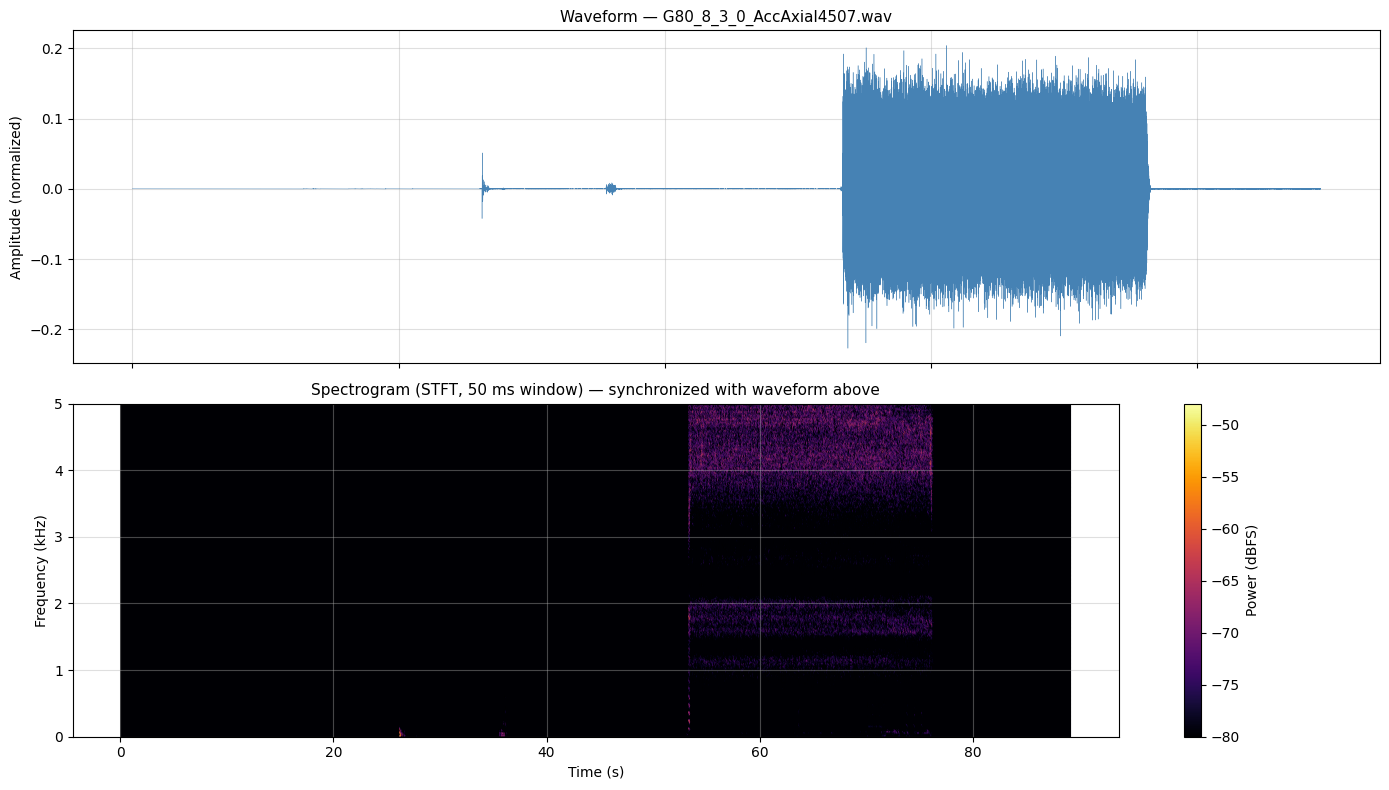

In [5]:
# Waveform and spectrogram plotted with SYNCHRONIZED time axes (sharex=True).
# Zooming or panning on either subplot automatically updates the other.
t = np.arange(len(signal)) / fs

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)  # sharex synchronizes both plots

# ── Waveform ──────────────────────────────────────────────────────────────────
axes[0].plot(t, signal, lw=0.3, color='steelblue')
axes[0].set_ylabel('Amplitude (normalized)')
axes[0].set_title(f'Waveform — {EXAMPLE_WAV.name}')

# ── Spectrogram ───────────────────────────────────────────────────────────────
nperseg = int(0.05 * fs)   # 50 ms window: good time–frequency trade-off
f_spec, t_spec, Sxx = sp_spectrogram(signal, fs=fs, nperseg=nperseg, noverlap=nperseg // 2)

# Limit frequency axis to 5 kHz for readability
f_max_hz = min(fs / 2, 5000)
f_mask   = f_spec <= f_max_hz

im = axes[1].pcolormesh(
    t_spec, f_spec[f_mask] / 1000,
    10 * np.log10(Sxx[f_mask] + 1e-12),   # +1e-12 avoids log10(0)
    shading='gouraud', cmap='inferno', vmin=-80
)
plt.colorbar(im, ax=axes[1], label='Power (dBFS)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (kHz)')
axes[1].set_title('Spectrogram (STFT, 50 ms window) — synchronized with waveform above')

plt.tight_layout()
plt.show(); plt.close('all')


## 2. Blast Detection

The blasting process begins when the operator opens the abrasive valve.
The first **6–8 seconds** contain a startup transient:
nozzle purge, valve opening noise, and pressure stabilisation.
Only after this period does the **useful steady-state signal** begin.

### Algorithm: Short-Time Energy Threshold

1. Divide the signal into short frames of `ENERGY_WINDOW_S` seconds.
2. Compute the **Root Mean Square (RMS)** energy of each frame:
   `E_k = sqrt( mean( x[k*hop : (k+1)*hop]^2 ) )`
3. Estimate the **noise floor** from the first `NOISE_DURATION_S` seconds.
4. Detect the **onset** as the first frame where:
   `E_k > ONSET_THRESHOLD * noise_floor`
5. The **useful signal** starts at: `t_onset + ONSET_OFFSET_S`

### Why 7 s offset?
The mentor specifies a 6–8 s startup window.
We use the midpoint (7 s) as a robust default.


In [6]:
def detect_blast_onset(signal, fs, energy_window_s=0.05, noise_duration_s=0.5, threshold=10.0):
    """
    Detect the onset of the blasting process using short-time RMS energy.

    Parameters
    ----------
    signal : ndarray
        Normalized audio signal.
    fs : int
        Sampling rate (Hz).
    energy_window_s : float
        Duration of each short-time energy frame (s).
    noise_duration_s : float
        Duration of the initial quiet region used to estimate the noise floor (s).
    threshold : float
        Onset is declared when frame energy exceeds (threshold × noise_floor).

    Returns
    -------
    onset_sample : int
    onset_time : float
    frame_times : ndarray
    rms_energy : ndarray
    noise_floor : float
    """
    hop      = int(energy_window_s * fs)
    n_frames = len(signal) // hop

    rms_energy = np.array([
        np.sqrt(np.mean(signal[i * hop : (i + 1) * hop] ** 2))
        for i in range(n_frames)
    ])
    frame_times = np.arange(n_frames) * energy_window_s

    noise_frames = max(1, int(noise_duration_s / energy_window_s))
    noise_floor  = np.mean(rms_energy[:noise_frames])

    above = np.where(rms_energy > threshold * noise_floor)[0]
    if len(above) == 0:
        onset_frame = int(np.argmax(rms_energy))
        print("Warning: threshold never exceeded — using peak energy frame as onset.")
    else:
        onset_frame = int(above[0])

    onset_sample = onset_frame * hop
    onset_time   = onset_frame * energy_window_s

    return onset_sample, onset_time, frame_times, rms_energy, noise_floor


onset_sample, onset_time, frame_times, rms_energy, noise_floor = detect_blast_onset(
    signal, fs,
    energy_window_s  = ENERGY_WINDOW_S,
    noise_duration_s = NOISE_DURATION_S,
    threshold        = ONSET_THRESHOLD,
)

useful_start_time   = onset_time + ONSET_OFFSET_S
useful_start_sample = int(useful_start_time * fs)
useful_signal       = signal[useful_start_sample:]

print(f"Noise floor (RMS)    : {noise_floor:.6f}")
print(f"Threshold level      : {ONSET_THRESHOLD * noise_floor:.6f}")
print(f"Blast onset          : {onset_time:.3f} s  (sample {onset_sample:,})")
print(f"Useful signal from   : {useful_start_time:.3f} s  (onset + {ONSET_OFFSET_S} s)")
print(f"Useful signal length : {len(useful_signal) / fs:.2f} s  ({len(useful_signal):,} samples)")


Noise floor (RMS)    : 0.000016
Threshold level      : 0.000157
Blast onset          : 13.600 s  (sample 652,800)
Useful signal from   : 20.600 s  (onset + 7.0 s)
Useful signal length : 68.65 s  (3,294,993 samples)


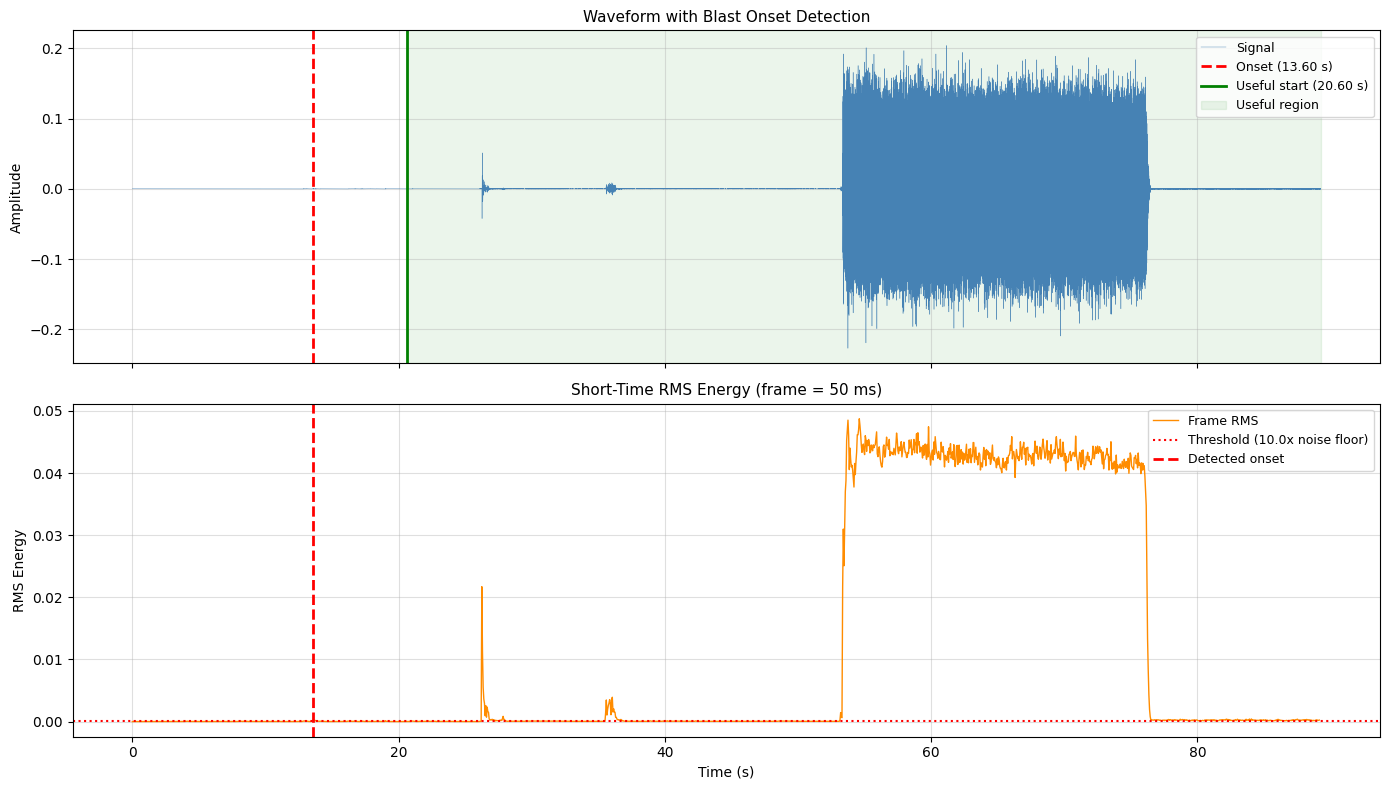

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(t, signal, lw=0.3, color='steelblue', label='Signal')
ax1.axvline(onset_time,        color='red',   lw=2, ls='--', label=f'Onset ({onset_time:.2f} s)')
ax1.axvline(useful_start_time, color='green', lw=2, ls='-',  label=f'Useful start ({useful_start_time:.2f} s)')
ax1.axvspan(useful_start_time, t[-1], alpha=0.08, color='green', label='Useful region')
ax1.set_ylabel('Amplitude')
ax1.set_title('Waveform with Blast Onset Detection')
ax1.legend(loc='upper right', fontsize=9)

ax2.plot(frame_times, rms_energy, color='darkorange', lw=1, label='Frame RMS')
ax2.axhline(ONSET_THRESHOLD * noise_floor, color='red', ls=':', lw=1.5,
            label=f'Threshold ({ONSET_THRESHOLD}x noise floor)')
ax2.axvline(onset_time, color='red', lw=2, ls='--', label='Detected onset')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('RMS Energy')
ax2.set_title(f'Short-Time RMS Energy (frame = {ENERGY_WINDOW_S*1000:.0f} ms)')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show(); plt.close('all')


## 3. Floating Analysis Windows

All calculations are performed on **short overlapping segments** of the useful signal.

### Window Parameters
| Parameter | Value | Description |
|-----------|-------|-------------|
| `WINDOW_DURATION_S` | 5 s | Length of each analysis window |
| `WINDOW_STEP_S` | 1 s | Step between consecutive window starts |
| Overlap | 80 % | `(1 − step/duration) × 100` |

The visualization below uses a **Gantt-style timeline** so each 5-second window is clearly visible
as a horizontal bar. Consecutive windows are staggered vertically to show the 80% overlap.


In [8]:
def create_floating_windows(signal, fs, window_s, step_s):
    """
    Generate overlapping (floating) analysis windows from a signal.

    Parameters
    ----------
    signal : ndarray
        Input signal (useful portion only).
    fs : int
        Sampling rate (Hz).
    window_s : float
        Window length in seconds.
    step_s : float
        Step between consecutive window starts (s).

    Returns
    -------
    windows : list of ndarray
    window_start_times : ndarray
        Start time (s) relative to the start of `signal`.
    """
    win_len  = int(window_s * fs)
    step_len = int(step_s * fs)
    n_wins   = max(0, (len(signal) - win_len) // step_len + 1)

    windows            = [signal[i * step_len : i * step_len + win_len] for i in range(n_wins)]
    window_start_times = np.arange(n_wins) * step_s

    return windows, window_start_times


windows, window_starts = create_floating_windows(
    useful_signal, fs, WINDOW_DURATION_S, WINDOW_STEP_S
)

overlap_pct = (1 - WINDOW_STEP_S / WINDOW_DURATION_S) * 100

print(f"Window length    : {WINDOW_DURATION_S} s  ({int(WINDOW_DURATION_S * fs):,} samples)")
print(f"Step size        : {WINDOW_STEP_S} s  ({int(WINDOW_STEP_S * fs):,} samples)")
print(f"Overlap          : {overlap_pct:.0f} %")
print(f"Number of windows: {len(windows)}")


Window length    : 5.0 s  (240,000 samples)
Step size        : 1.0 s  (48,000 samples)
Overlap          : 80 %
Number of windows: 64


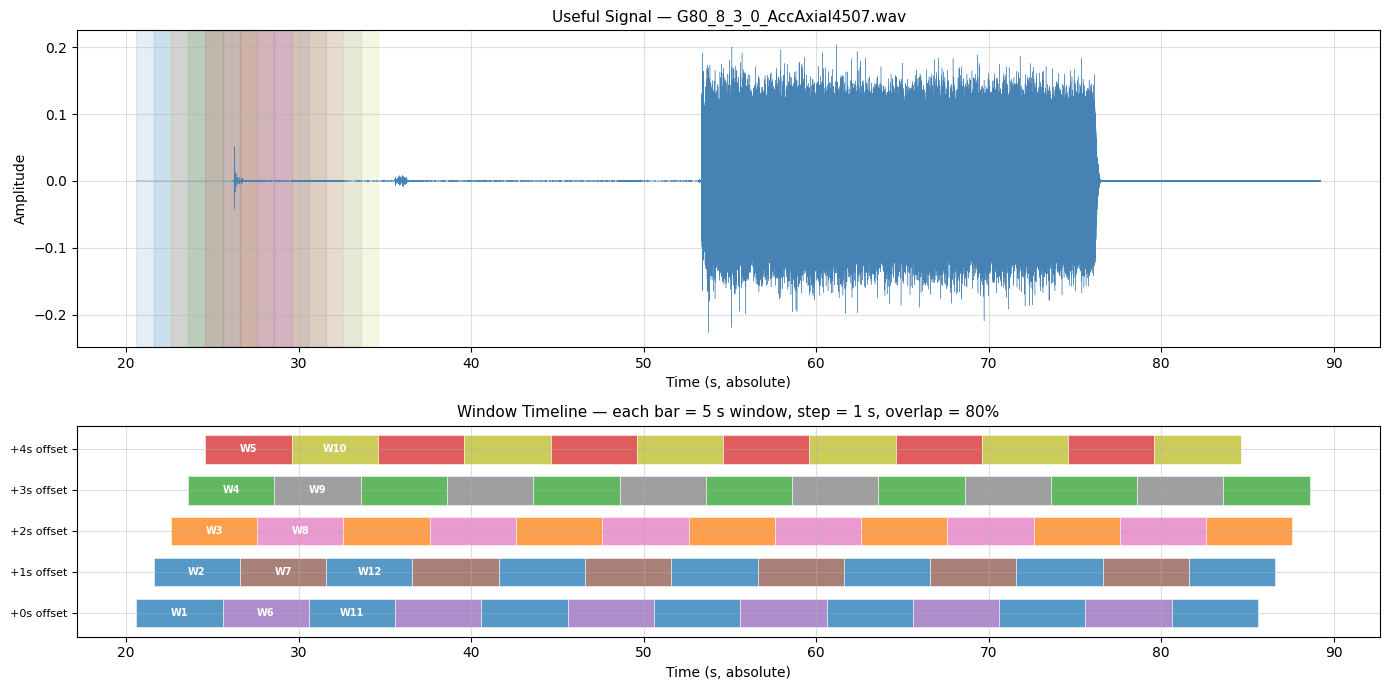

Total windows: 64  |  Window duration: 5.0 s  |  Step: 1.0 s  |  Overlap: 80%


In [9]:
# ── Floating window visualization (redesigned) ────────────────────────────────
# Problem with simple axvspan: 5s windows stepping 1s appear as 1s bars because
# overlapping spans blend into each other.
# Solution: Gantt-style chart below the waveform — each window is a separate bar
# drawn at a staggered Y level to show the 80% overlap structure clearly.

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7),
                                 gridspec_kw={'height_ratios': [3, 2]})

t_useful_abs = np.arange(len(useful_signal)) / fs + useful_start_time

# ── Top: Waveform with first few windows lightly shaded ──────────────────────
ax1.plot(t_useful_abs, useful_signal, lw=0.3, color='steelblue', label='Useful signal')
colors = plt.cm.tab10(np.linspace(0, 0.8, min(len(windows), 10)))
n_label = min(len(windows), 5)
for i in range(min(len(windows), 10)):
    abs_start = useful_start_time + window_starts[i]
    ax1.axvspan(abs_start, abs_start + WINDOW_DURATION_S,
                alpha=0.12, color=colors[i])
ax1.set_ylabel('Amplitude')
ax1.set_title(f'Useful Signal — {EXAMPLE_WAV.name}')
ax1.set_xlabel('Time (s, absolute)')

# ── Bottom: Gantt-style timeline showing every window as a 5-second bar ──────
# Windows are stacked at Y = i % n_rows to reveal the overlap structure.
n_stack = int(WINDOW_DURATION_S / WINDOW_STEP_S)   # how many windows overlap = 5

for i, start_s in enumerate(window_starts):
    abs_start = useful_start_time + start_s
    y_level   = i % n_stack                         # stagger vertically
    ax2.barh(y_level, WINDOW_DURATION_S, left=abs_start,
             height=0.7, color=colors[i % len(colors)], alpha=0.75, edgecolor='white', lw=0.5)
    if i < 12:   # label first 12 windows
        ax2.text(abs_start + WINDOW_DURATION_S / 2, y_level, f'W{i+1}',
                 ha='center', va='center', fontsize=7, color='white', fontweight='bold')

ax2.set_yticks(range(n_stack))
ax2.set_yticklabels([f'+{j}s offset' for j in range(n_stack)], fontsize=8)
ax2.set_xlabel('Time (s, absolute)')
ax2.set_title(f'Window Timeline — each bar = {WINDOW_DURATION_S:.0f} s window, '
              f'step = {WINDOW_STEP_S:.0f} s, overlap = {overlap_pct:.0f}%')
ax2.set_xlim(ax1.get_xlim())

plt.tight_layout()
plt.show(); plt.close('all')

print(f"Total windows: {len(windows)}  |  Window duration: {WINDOW_DURATION_S} s  |  Step: {WINDOW_STEP_S} s  |  Overlap: {overlap_pct:.0f}%")


## 4. Bandpass Filter Design

### Filter Type Overview

| Type | Passband | Stopband | Group Delay | Selectivity |
|------|----------|----------|-------------|-------------|
| **Butterworth** | Maximally flat | Monotone | Moderate | Moderate |
| **Chebyshev I** | Equiripple (±rp dB) | Monotone | Higher distortion | Good |
| **Chebyshev II** | Monotone | Equiripple (–rs dB) | Moderate | Good |
| **Elliptical** | Equiripple | Equiripple | Highest distortion | Best |
| **Bessel** | Monotone | Gradual rolloff | **Linear** (best phase) | Poor |

All filters use **Second-Order Sections (SOS)** form for numerical stability.
`sosfiltfilt` performs **zero-phase** (forward + backward) filtering.


In [10]:
def design_bandpass_filter(filter_type, order, low_hz, high_hz, fs):
    """
    Design a digital bandpass filter in SOS form.

    Parameters
    ----------
    filter_type : str
        'Butterworth', 'Chebyshev I', 'Chebyshev II', 'Elliptical', or 'Bessel'.
    order : int
        Filter order (3, 5, or 7).
    low_hz, high_hz : float
        Cutoff frequencies (Hz).
    fs : int
        Sampling rate (Hz).

    Returns
    -------
    sos : ndarray, shape (n_sections, 6)
    """
    nyq = fs / 2.0
    Wn  = [low_hz / nyq, high_hz / nyq]

    if filter_type == 'Butterworth':
        sos = butter(order, Wn, btype='bandpass', output='sos')
    elif filter_type == 'Chebyshev I':
        sos = cheby1(order, CHEBY1_RIPPLE_DB, Wn, btype='bandpass', output='sos')
    elif filter_type == 'Chebyshev II':
        sos = cheby2(order, CHEBY2_ATTEN_DB, Wn, btype='bandpass', output='sos')
    elif filter_type == 'Elliptical':
        sos = ellip(order, ELLIP_RIPPLE_DB, ELLIP_ATTEN_DB, Wn, btype='bandpass', output='sos')
    elif filter_type == 'Bessel':
        sos = bessel(order, Wn, btype='bandpass', output='sos', norm='phase')
    else:
        raise ValueError(f"Unknown filter type: '{filter_type}'")

    return sos


def filter_complexity(sos):
    """
    Estimate arithmetic operations per output sample for a SOS filter.
    Each 2nd-order section: 5 multiplications + 4 additions = 9 ops/sample.
    """
    n = len(sos)
    return {'n_sections': n, 'multiplications': 5*n, 'additions': 4*n, 'total_operations': 9*n}


# Pre-design and cache all (filter_type, order, band) combinations
filter_cache  = {}
design_errors = []

for ftype, order, (lo, hi) in product(FILTER_TYPES, FILTER_ORDERS, zip(LOWER_LIMITS, UPPER_LIMITS)):
    key = (ftype, order, lo, hi)
    try:
        filter_cache[key] = design_bandpass_filter(ftype, order, lo, hi, fs)
    except Exception as e:
        design_errors.append(f"{ftype} N={order} band {lo}–{hi} Hz: {e}")
        filter_cache[key] = None

n_ok   = sum(v is not None for v in filter_cache.values())
n_fail = len(design_errors)
print(f"Filters designed successfully : {n_ok}")
print(f"Design failures               : {n_fail}")
for err in design_errors[:10]:
    print(f"  FAIL: {err}")


Filters designed successfully : 225
Design failures               : 0


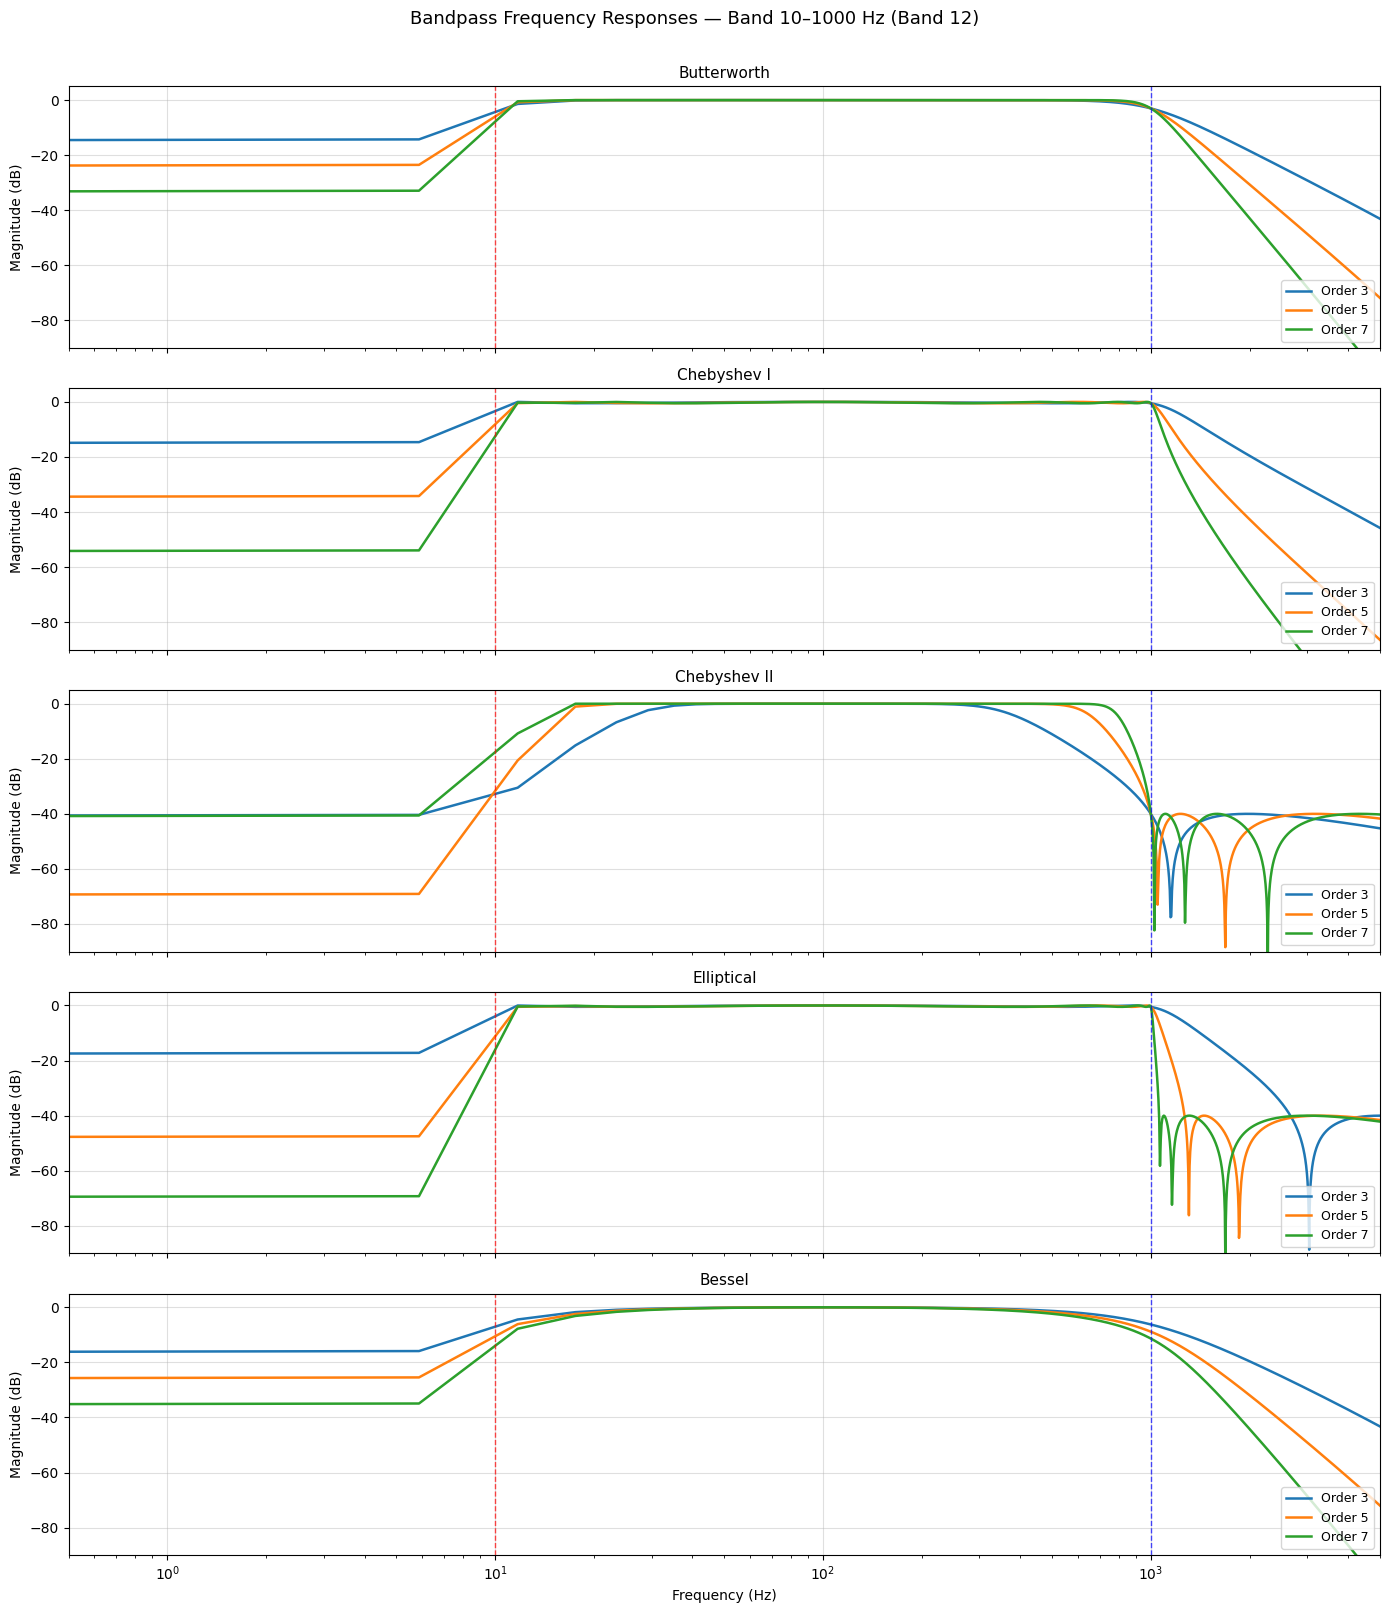

In [11]:
# Frequency responses for one representative band: 10–1000 Hz (Band 12)
DEMO_BAND = 11
lo_demo   = LOWER_LIMITS[DEMO_BAND]
hi_demo   = UPPER_LIMITS[DEMO_BAND]
N_PTS     = 4096

fig, axes = plt.subplots(len(FILTER_TYPES), 1, figsize=(14, 16), sharex=True)

for ax, ftype in zip(axes, FILTER_TYPES):
    for order in FILTER_ORDERS:
        sos = filter_cache.get((ftype, order, lo_demo, hi_demo))
        if sos is None:
            continue
        w, h = sosfreqz(sos, worN=N_PTS, fs=fs)
        ax.plot(w, 20 * np.log10(np.abs(h) + 1e-12), label=f'Order {order}', lw=1.8)

    ax.axvline(lo_demo, color='red',  ls='--', lw=1, alpha=0.7)
    ax.axvline(hi_demo, color='blue', ls='--', lw=1, alpha=0.7)
    ax.set_xlim(lo_demo * 0.05, hi_demo * 5)
    ax.set_ylim(-90, 5)
    ax.set_ylabel('Magnitude (dB)')
    ax.set_title(ftype)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xscale('log')

axes[-1].set_xlabel('Frequency (Hz)')
fig.suptitle(f'Bandpass Frequency Responses — Band {lo_demo}–{hi_demo} Hz (Band {DEMO_BAND+1})',
             fontsize=13, y=1.005)
plt.tight_layout()
plt.show(); plt.close('all')


## 5. Signal Parameter Extraction

For each filtered window, six parameters are computed:

| Parameter | Formula | Physical Meaning |
|-----------|---------|-----------------|
| **RMS** | `sqrt( mean(x²) )` | Signal power; proportional to energy density |
| **Peak** | `max|x|` | Maximum instantaneous amplitude |
| **Crest Factor** | `Peak / RMS` | Impulsiveness; high CF = spike-dominated signal |
| **Zero Crossing Rate** | `(count of sign changes) / (2 × duration)` | Proxy for dominant frequency |
| **Band Power** | `trapz(PSD, f)` via Welch | Spectral energy concentrated in the passband |
| **Spectral Centroid** | `sum(f·S) / sum(S)` | Frequency centre-of-mass of the spectrum |

### Next cell: individual calculation time for each parameter on a 5-second window.


In [12]:
def compute_parameters(x, fs):
    """
    Compute six signal descriptors for a filtered analysis window.

    Returns dict: rms, peak, crest_factor, zcr, band_power, spectral_centroid.
    Also returns timing_us: dict of per-parameter calculation time (microseconds).
    """
    timings = {}

    # ── RMS ───────────────────────────────────────────────────────────────────
    t0  = time.perf_counter()
    rms = np.sqrt(np.mean(x ** 2))
    timings['rms'] = (time.perf_counter() - t0) * 1e6

    # ── Peak ──────────────────────────────────────────────────────────────────
    t0   = time.perf_counter()
    peak = float(np.max(np.abs(x)))
    timings['peak'] = (time.perf_counter() - t0) * 1e6

    # ── Crest Factor ──────────────────────────────────────────────────────────
    t0           = time.perf_counter()
    crest_factor = peak / rms if rms > 1e-12 else 0.0
    timings['crest_factor'] = (time.perf_counter() - t0) * 1e6

    # ── Zero Crossing Rate ────────────────────────────────────────────────────
    t0          = time.perf_counter()
    signs       = np.sign(x)
    n_crossings = np.sum(np.abs(np.diff(signs)) > 0)
    zcr         = n_crossings / (2.0 * (len(x) - 1) / fs)
    timings['zcr'] = (time.perf_counter() - t0) * 1e6

    # ── Band Power via Welch PSD ──────────────────────────────────────────────
    t0       = time.perf_counter()
    nperseg  = min(1024, len(x) // 4)
    f_psd, psd = welch(x, fs=fs, nperseg=nperseg, window='hann')
    band_power = float(np.trapz(psd, f_psd))
    timings['band_power'] = (time.perf_counter() - t0) * 1e6

    # ── Spectral Centroid ─────────────────────────────────────────────────────
    t0                = time.perf_counter()
    psd_sum           = np.sum(psd)
    spectral_centroid = float(np.sum(f_psd * psd) / psd_sum) if psd_sum > 0 else 0.0
    timings['spectral_centroid'] = (time.perf_counter() - t0) * 1e6

    return {
        'rms'              : float(rms),
        'peak'             : peak,
        'crest_factor'     : crest_factor,
        'zcr'              : zcr,
        'band_power'       : band_power,
        'spectral_centroid': spectral_centroid,
    }, timings


  Filter (sosfiltfilt)          :  8340.46 μs  (±1233.73)
  RMS                           :   869.95 μs  (±198.30)


  Peak                          :   799.58 μs  (±162.61)


  Crest Factor                  :  1625.42 μs  (±352.11)


  Zero Crossing Rate            :  2434.22 μs  (±455.73)


  Band Power (Welch)            : 13445.41 μs  (±2884.69)


  Spectral Centroid             : 13468.73 μs  (±1804.46)


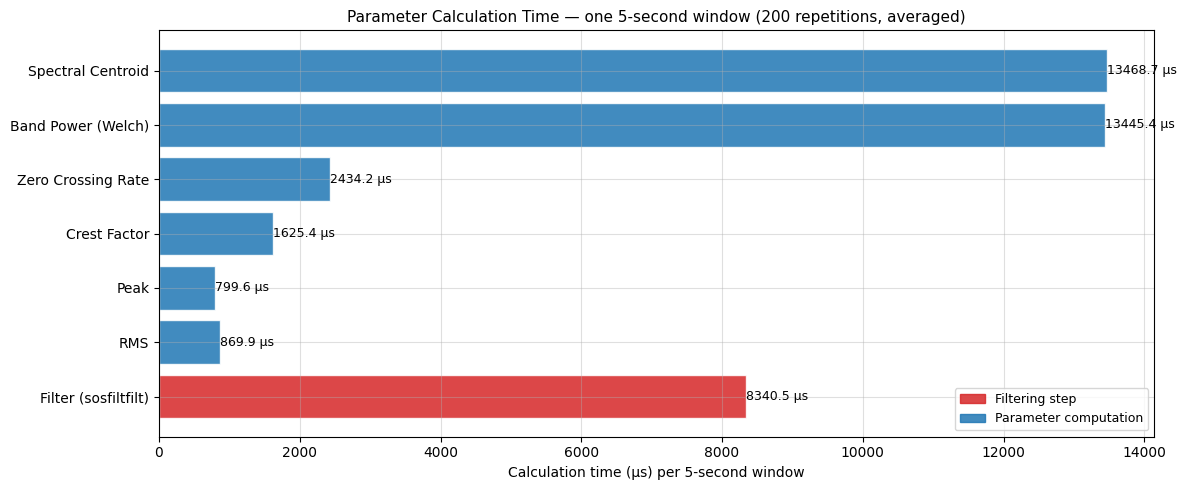


Total time per window (filter + all params): 40983.8 μs  = 40.984 ms


In [13]:
# ── Parameter Calculation Timing ──────────────────────────────────────────────
# Measures how long it takes to compute each parameter on one 5-second window.
# Uses a representative filtered window (Butterworth order 5, band 10–1000 Hz).
# N_TIMING_REPS repetitions to reduce measurement noise.

N_TIMING_REPS = 200

# Get a representative filtered window for timing
_demo_sos = filter_cache.get(('Butterworth', 5, LOWER_LIMITS[11], UPPER_LIMITS[11]))
_demo_win = windows[0] if windows else np.zeros(int(WINDOW_DURATION_S * fs))
x_demo    = sosfiltfilt(_demo_sos, _demo_win) if _demo_sos is not None else _demo_win

# ── Time the filtering step ───────────────────────────────────────────────────
filter_times_us = []
for _ in range(N_TIMING_REPS):
    t0 = time.perf_counter()
    sosfiltfilt(_demo_sos, _demo_win)
    filter_times_us.append((time.perf_counter() - t0) * 1e6)

mean_filter_us = np.mean(filter_times_us)

# ── Time each parameter individually ─────────────────────────────────────────
param_fns = {
    'Filter (sosfiltfilt)': lambda x: sosfiltfilt(_demo_sos, _demo_win),
    'RMS'                 : lambda x: np.sqrt(np.mean(x ** 2)),
    'Peak'                : lambda x: float(np.max(np.abs(x))),
    'Crest Factor'        : lambda x: float(np.max(np.abs(x))) / max(float(np.sqrt(np.mean(x**2))), 1e-12),
    'Zero Crossing Rate'  : lambda x: np.sum(np.abs(np.diff(np.sign(x))) > 0) / (2.0*(len(x)-1)/fs),
    'Band Power (Welch)'  : lambda x: float(np.trapz(*reversed(welch(x, fs=fs, nperseg=min(1024,len(x)//4))))),
    'Spectral Centroid'   : lambda x: (lambda fp, ps: float(np.sum(fp*ps)/max(np.sum(ps),1e-12)))
                                      (*welch(x, fs=fs, nperseg=min(1024,len(x)//4))),
}

param_timings_us = {}
for name, fn in param_fns.items():
    times = []
    for _ in range(N_TIMING_REPS):
        t0 = time.perf_counter()
        fn(x_demo)
        times.append((time.perf_counter() - t0) * 1e6)
    param_timings_us[name] = np.mean(times)
    print(f"  {name:<30}: {np.mean(times):8.2f} μs  (±{np.std(times):.2f})")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
names  = list(param_timings_us.keys())
values = list(param_timings_us.values())
colors_bar = ['#d62728' if 'Filter' in n else '#1f77b4' for n in names]
bars = ax.barh(names, values, color=colors_bar, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} μs', va='center', fontsize=9)

ax.set_xlabel('Calculation time (μs) per 5-second window')
ax.set_title(f'Parameter Calculation Time — one {WINDOW_DURATION_S:.0f}-second window '
             f'({N_TIMING_REPS} repetitions, averaged)')
legend_patches = [
    mpatches.Patch(color='#d62728', alpha=0.85, label='Filtering step'),
    mpatches.Patch(color='#1f77b4', alpha=0.85, label='Parameter computation'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show(); plt.close('all')

total_per_window_us = sum(param_timings_us.values())
print(f"\nTotal time per window (filter + all params): {total_per_window_us:.1f} μs  = {total_per_window_us/1000:.3f} ms")


## 6. Multi-file Analysis

The loop below processes **all selected WAV files** automatically:

For each file:
1. Load signal
2. Detect blast onset → skip startup transient
3. Create floating analysis windows
4. Apply all filter × order × band combinations
5. Compute all 6 signal parameters per window
6. Record per-step timing (filter time, RMS time, CF time)

Results are stored in a single DataFrame `df` with columns for filename and sensor type,
so all files can be compared in the same visualizations.


In [14]:
# ── Multi-file Analysis Loop ──────────────────────────────────────────────────
# Processes every WAV file in SELECTED_FILES (accelerometers first, then microphones).
import gc

all_results = []
timing      = {}   # (filter_type, order, band_idx) -> mean filter time (s), accumulated
_iter_count = 0

print(f"Processing {len(SELECTED_FILES)} file(s)...")

for file_idx, wav_path in enumerate(SELECTED_FILES):
    print(f"\n[{file_idx+1}/{len(SELECTED_FILES)}] {wav_path.name}")

    try:
        fs_f, sig_f, dur_f = load_wav(wav_path)
    except Exception as e:
        print(f"  ERROR loading: {e}")
        continue

    # Detect onset and extract useful signal
    _, onset_t, _, _, _ = detect_blast_onset(
        sig_f, fs_f, ENERGY_WINDOW_S, NOISE_DURATION_S, ONSET_THRESHOLD
    )
    useful_start_t = onset_t + ONSET_OFFSET_S
    useful_sig_f   = sig_f[int(useful_start_t * fs_f):]

    # Create floating windows
    wins_f, win_starts_f = create_floating_windows(useful_sig_f, fs_f, WINDOW_DURATION_S, WINDOW_STEP_S)
    if len(wins_f) == 0:
        print(f"  SKIP: no windows (signal too short after onset skip)")
        continue

    print(f"  Onset: {onset_t:.2f}s | Useful from: {useful_start_t:.2f}s | Windows: {len(wins_f)}")

    # Re-design filters for this file's sample rate (may differ across files)
    fc = {}
    for ftype, order, (lo, hi) in product(FILTER_TYPES, FILTER_ORDERS, zip(LOWER_LIMITS, UPPER_LIMITS)):
        key = (ftype, order, lo, hi)
        try:
            fc[key] = design_bandpass_filter(ftype, order, lo, hi, fs_f)
        except Exception:
            fc[key] = None

    # Parse sensor from filename
    stem   = wav_path.stem
    parts  = stem.split('_')
    sensor = parts[-1] if parts[-1] in SENSOR_PRIORITY else 'unknown'

    # Inner loop: filter × order × band × window
    for ftype in FILTER_TYPES:
        for order in FILTER_ORDERS:
            for band_idx, (lo, hi) in enumerate(zip(LOWER_LIMITS, UPPER_LIMITS)):
                sos = fc.get((ftype, order, lo, hi))
                if sos is None:
                    continue

                filter_times_s = []

                for win_idx, window in enumerate(wins_f):
                    # Measure filter time
                    t0          = time.perf_counter()
                    x_filtered  = sosfiltfilt(sos, window)
                    filter_time = time.perf_counter() - t0

                    # Measure RMS time
                    t0 = time.perf_counter()
                    rms_val = np.sqrt(np.mean(x_filtered ** 2))
                    rms_time_us = (time.perf_counter() - t0) * 1e6

                    # Measure CF time
                    t0 = time.perf_counter()
                    cf_val = float(np.max(np.abs(x_filtered))) / max(rms_val, 1e-12)
                    cf_time_us = (time.perf_counter() - t0) * 1e6

                    # Compute remaining parameters
                    params, _ = compute_parameters(x_filtered, fs_f)
                    filter_times_s.append(filter_time)

                    _iter_count += 1
                    if _iter_count % 500 == 0:
                        gc.collect()

                    all_results.append({
                        'filename'        : wav_path.name,
                        'sensor'          : sensor,
                        'file_idx'        : file_idx,
                        'filter_type'     : ftype,
                        'order'           : order,
                        'band_idx'        : band_idx,
                        'band_label'      : BAND_LABELS[band_idx],
                        'low_hz'          : lo,
                        'high_hz'         : hi,
                        'window_idx'      : win_idx,
                        'window_start_s'  : win_starts_f[win_idx] + useful_start_t,
                        'filter_time_ms'  : filter_time * 1000,
                        'rms_time_us'     : rms_time_us,
                        'cf_time_us'      : cf_time_us,
                        **params,
                    })

                key_t = (ftype, order, band_idx)
                timing[key_t] = float(np.mean(filter_times_s))

df = pd.DataFrame(all_results)
print(f"\nAnalysis complete.")
print(f"  Total result rows : {len(df):,}")
print(f"  Files processed   : {df['filename'].nunique()}")
print(f"  Sensors           : {sorted(df['sensor'].unique(), key=lambda s: SENSOR_PRIORITY.index(s) if s in SENSOR_PRIORITY else 99)}")
df.head(3)


Processing 2 file(s)...

[1/2] G80_8_3_0_AccAxial4507.wav
  Onset: 13.60s | Useful from: 20.60s | Windows: 64



[2/2] GH40_6_6.5_0_AccAxial4507.wav
  Onset: 3.90s | Useful from: 10.90s | Windows: 18



Analysis complete.
  Total result rows : 18,450
  Files processed   : 2
  Sensors           : ['AccAxial4507']


,filename,sensor,file_idx,filter_type,order,band_idx,band_label,low_hz,high_hz,window_idx,window_start_s,filter_time_ms,rms_time_us,cf_time_us,rms,peak,crest_factor,zcr,band_power,spectral_centroid
0,G80_8_3_0_AccAxial4507.wav,AccAxial4507,0,Butterworth,3,0,176–225 Hz,176,225,0,20.6,7.0285,1003.800004,664.000007,0.000001,0.000005,4.145281,199.400831,1.312730e-12,198.541477
1,G80_8_3_0_AccAxial4507.wav,AccAxial4507,0,Butterworth,3,0,176–225 Hz,176,225,1,21.6,7.0367,994.600006,782.200004,0.000032,0.000572,17.652435,198.800828,1.053608e-09,199.993900
2,G80_8_3_0_AccAxial4507.wav,AccAxial4507,0,Butterworth,3,0,176–225 Hz,176,225,2,22.6,7.2527,1055.400004,838.699998,0.000036,0.000572,15.836417,199.400831,1.310087e-09,200.464150


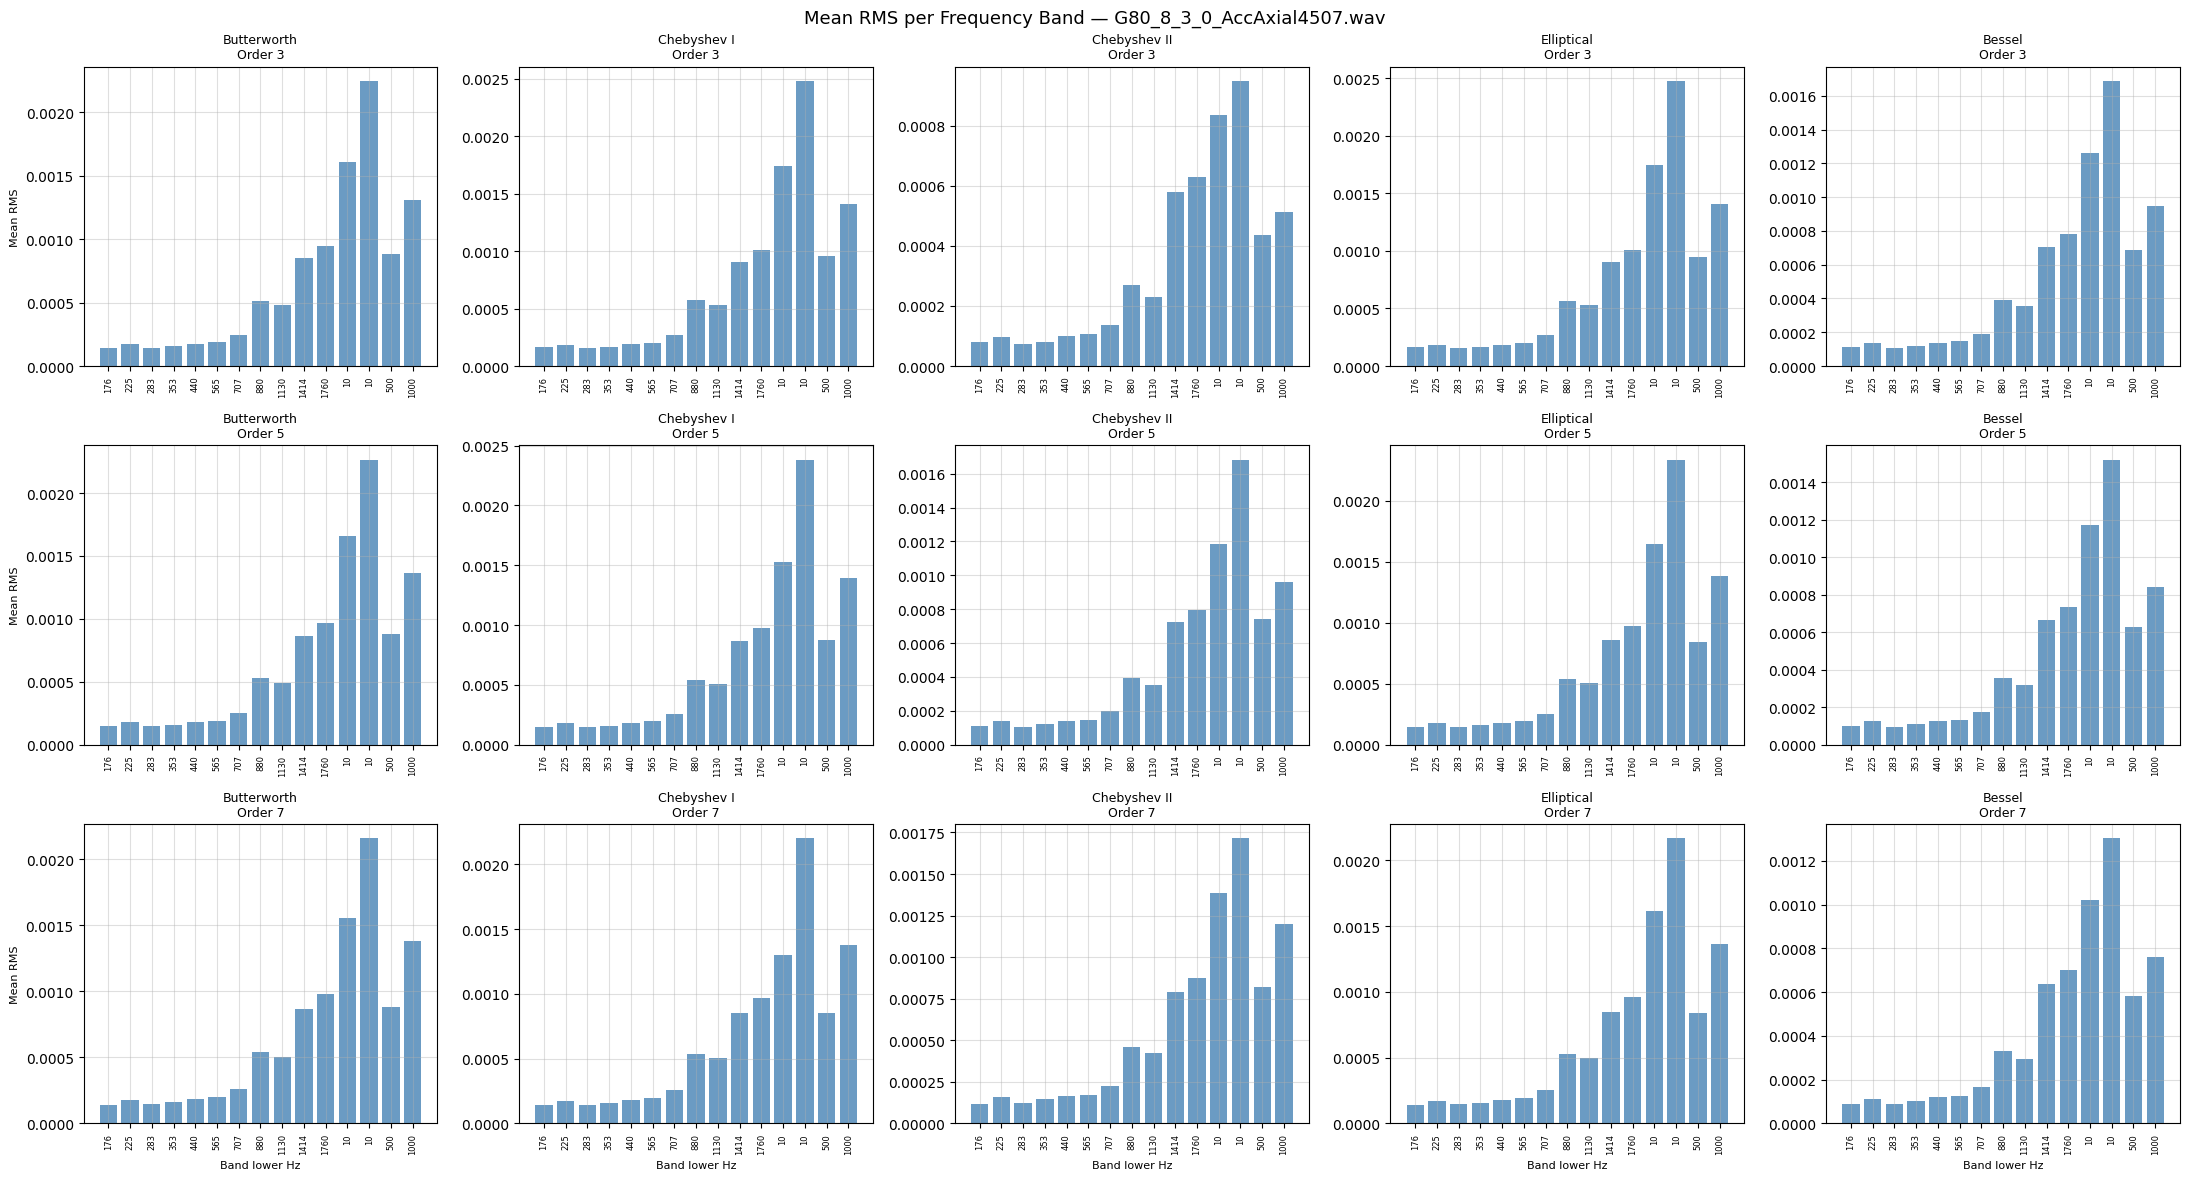

In [15]:
# Mean RMS per frequency band — averaged over all windows and files.
# Each subplot = one filter type × order combination.
# Accelerometer and microphone sensors produce different RMS levels (plotted separately).

# Use first file as reference for the standard bar chart
df_first = df[df['file_idx'] == 0] if 'file_idx' in df.columns else df

fig, axes = plt.subplots(len(FILTER_ORDERS), len(FILTER_TYPES),
                         figsize=(22, 12), sharey=False)

for row, order in enumerate(FILTER_ORDERS):
    for col, ftype in enumerate(FILTER_TYPES):
        ax      = axes[row, col]
        subset  = df_first[(df_first.filter_type == ftype) & (df_first.order == order)]
        mean_rms = subset.groupby('band_idx')['rms'].mean()
        values   = mean_rms.reindex(range(N_BANDS), fill_value=0.0)

        ax.bar(range(N_BANDS), values, color='steelblue', alpha=0.8)
        ax.set_title(f'{ftype}\nOrder {order}', fontsize=9)
        ax.set_xticks(range(N_BANDS))
        ax.set_xticklabels([f'{lo}' for lo in LOWER_LIMITS], rotation=90, fontsize=6)

        if col == 0:
            ax.set_ylabel('Mean RMS', fontsize=8)
        if row == len(FILTER_ORDERS) - 1:
            ax.set_xlabel('Band lower Hz', fontsize=8)

first_name = df_first['filename'].iloc[0] if len(df_first) > 0 else 'file 1'
fig.suptitle(f'Mean RMS per Frequency Band — {first_name}', fontsize=13)
plt.tight_layout()
plt.show(); plt.close('all')


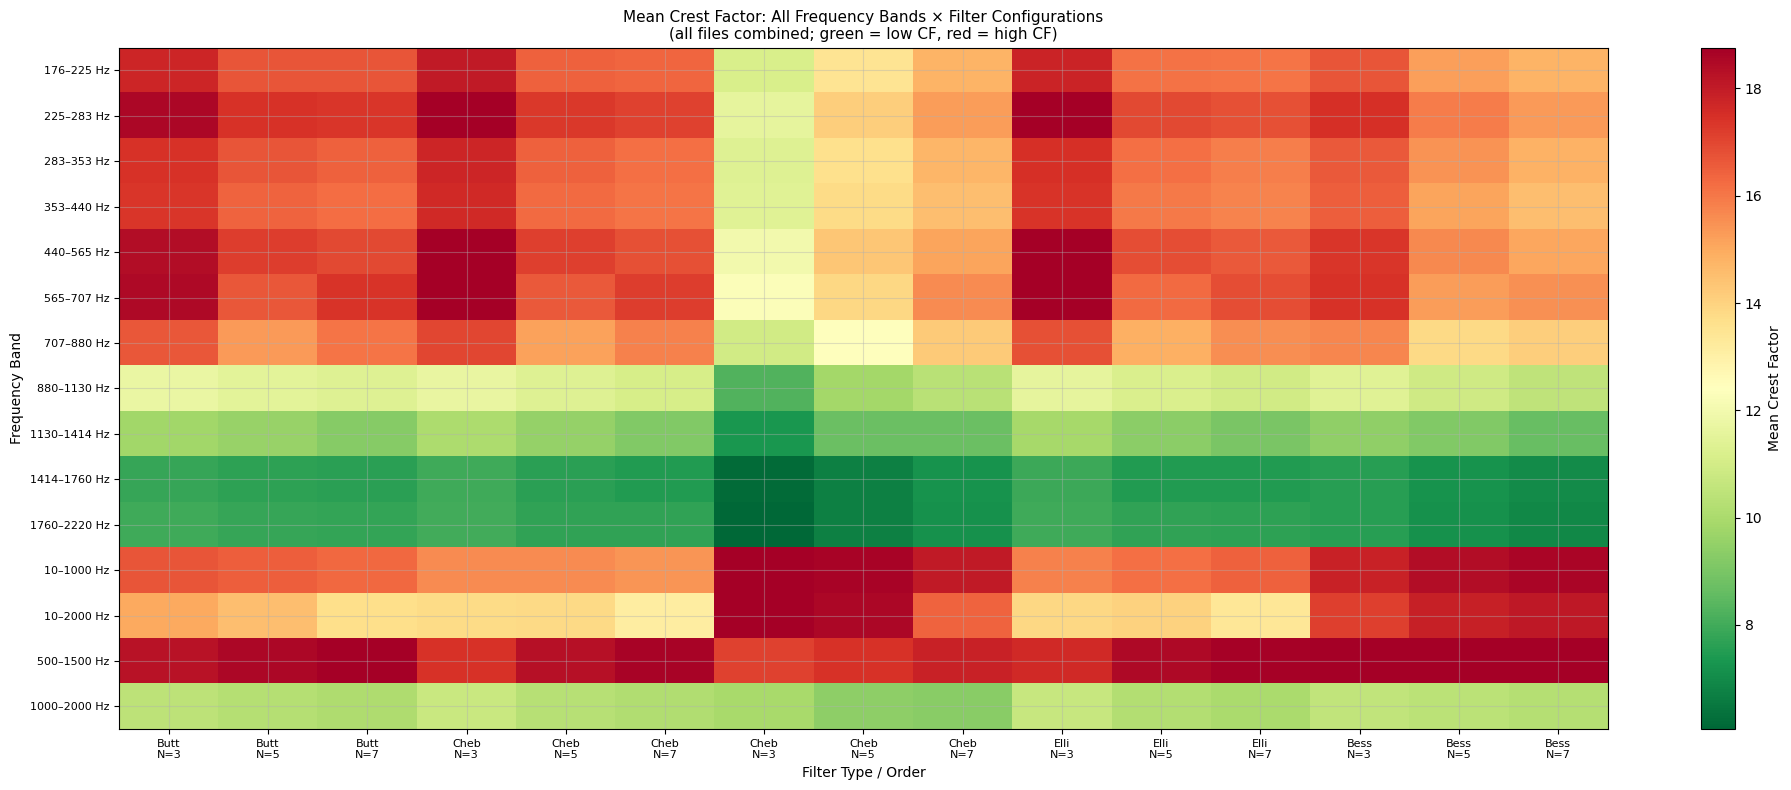

In [16]:
# Crest Factor heatmap: rows = frequency bands, columns = filter type × order.
# Shows average CF across all windows and files.
combo_labels = [f"{ft[:4]}\nN={o}" for ft, o in product(FILTER_TYPES, FILTER_ORDERS)]
n_combos_hm  = len(FILTER_TYPES) * len(FILTER_ORDERS)
cf_matrix    = np.full((N_BANDS, n_combos_hm), np.nan)

for col, (ftype, order) in enumerate(product(FILTER_TYPES, FILTER_ORDERS)):
    for row in range(N_BANDS):
        sub = df[(df.filter_type == ftype) & (df.order == order) & (df.band_idx == row)]
        if len(sub) > 0:
            cf_matrix[row, col] = sub['crest_factor'].mean()

fig, ax = plt.subplots(figsize=(20, 8))
im = ax.imshow(cf_matrix, aspect='auto', cmap='RdYlGn_r', interpolation='nearest',
               vmin=np.nanmin(cf_matrix), vmax=np.nanpercentile(cf_matrix, 95))
plt.colorbar(im, ax=ax, label='Mean Crest Factor')

ax.set_xticks(range(n_combos_hm))
ax.set_xticklabels(combo_labels, fontsize=8)
ax.set_yticks(range(N_BANDS))
ax.set_yticklabels(BAND_LABELS, fontsize=8)
ax.set_xlabel('Filter Type / Order')
ax.set_ylabel('Frequency Band')
ax.set_title('Mean Crest Factor: All Frequency Bands × Filter Configurations\n'
             '(all files combined; green = low CF, red = high CF)')
plt.tight_layout()
plt.show(); plt.close('all')


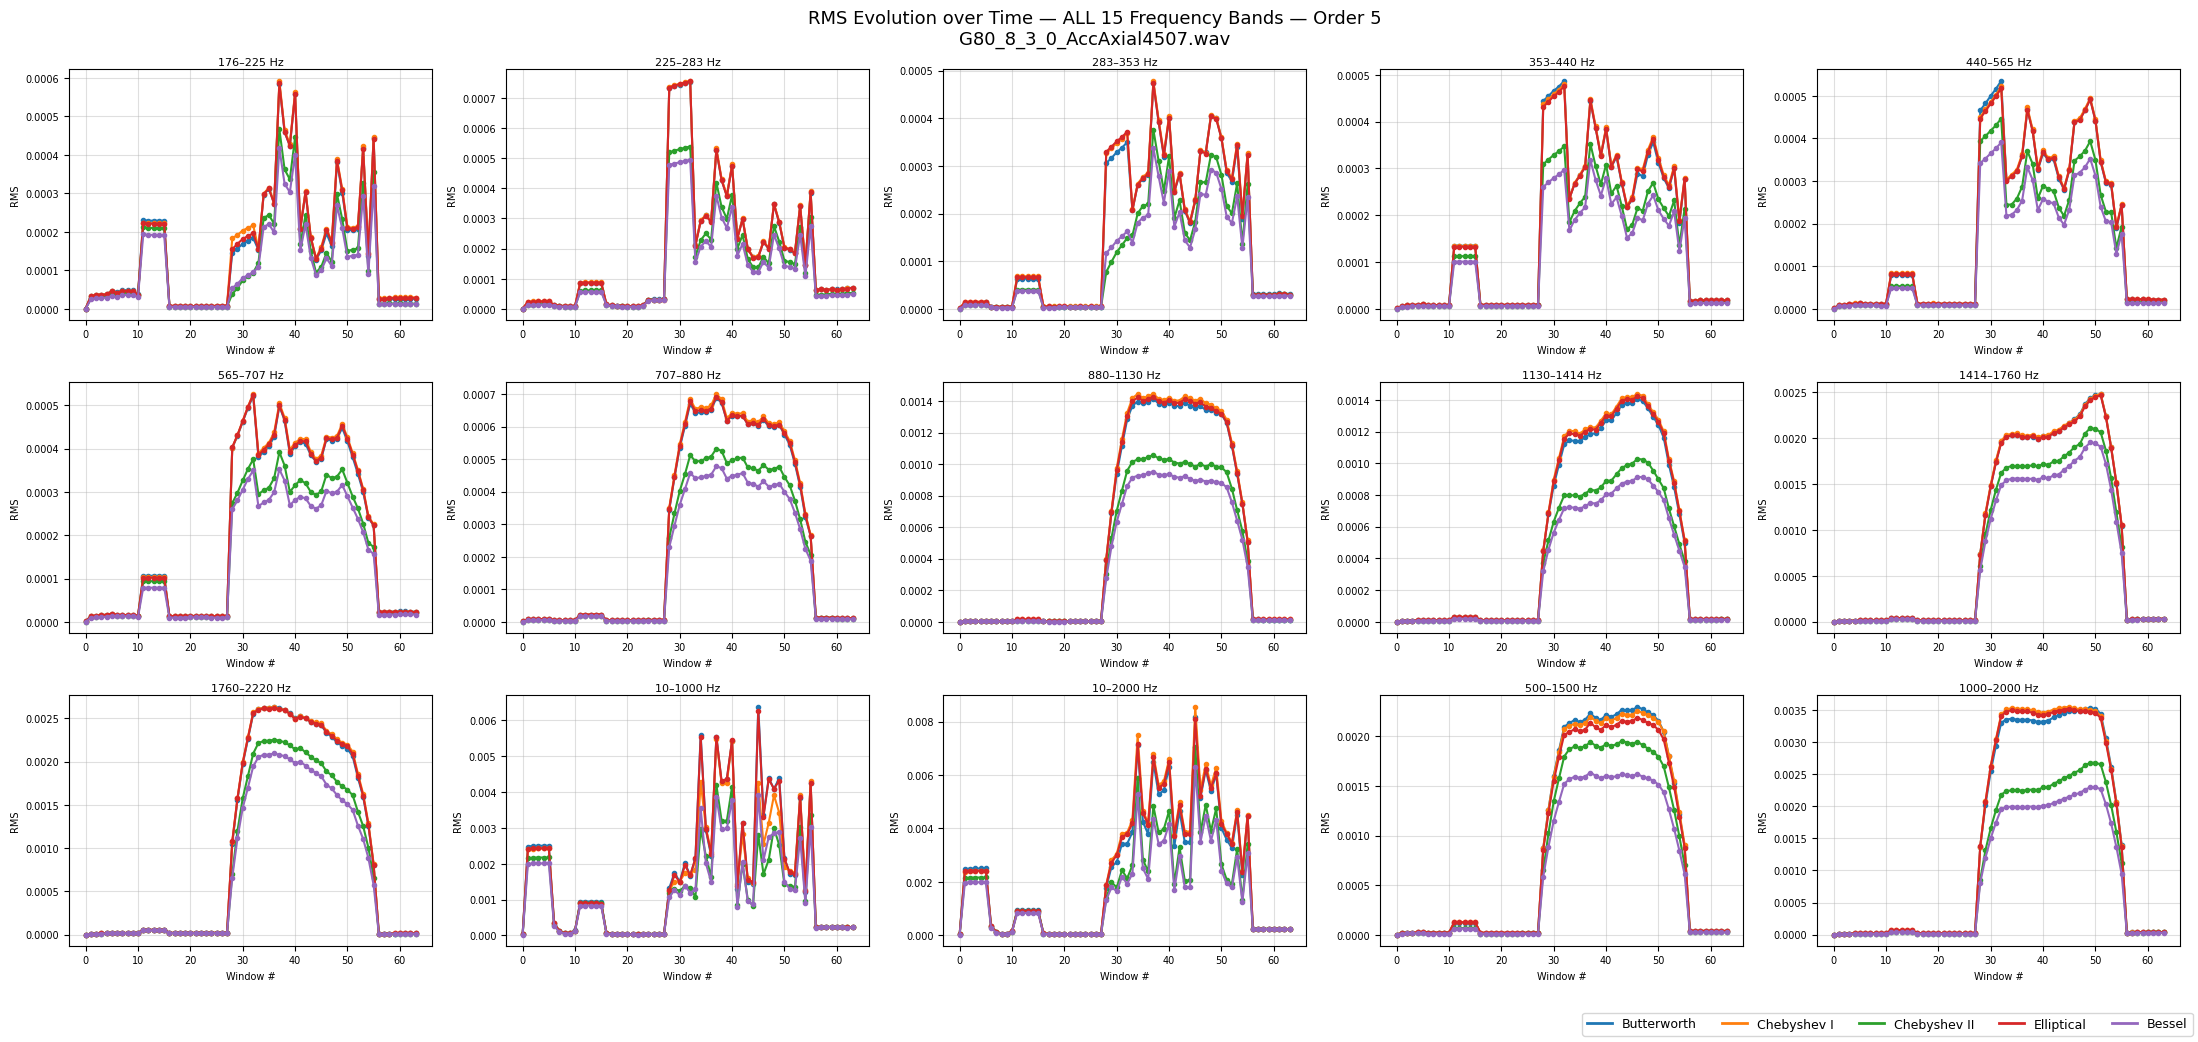

In [17]:
# ── RMS time evolution for ALL 15 frequency bands ─────────────────────────────
# Grid: 5 columns (bands 1–5, 6–10, 11–15 per row), 3 rows.
# Each subplot shows RMS vs window index for all 5 filter types at FOCUS_ORDER.
# Accelerometers and microphones are separated by linestyle.

FOCUS_ORDER = 5

# Use first file as reference
df_ref     = df[df['file_idx'] == 0] if 'file_idx' in df.columns else df
ref_name   = df_ref['filename'].iloc[0] if len(df_ref) > 0 else ''

n_cols = 5
n_rows = int(np.ceil(N_BANDS / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 3.5), sharey=False)
axes_flat = axes.flatten()

filter_colors = {'Butterworth': '#1f77b4', 'Chebyshev I': '#ff7f0e',
                 'Chebyshev II': '#2ca02c', 'Elliptical': '#d62728', 'Bessel': '#9467bd'}

for band_idx in range(N_BANDS):
    ax = axes_flat[band_idx]
    for ftype in FILTER_TYPES:
        sub = df_ref[
            (df_ref.filter_type == ftype) &
            (df_ref.order == FOCUS_ORDER) &
            (df_ref.band_idx == band_idx)
        ].sort_values('window_idx')

        if len(sub) == 0:
            continue
        ax.plot(sub['window_idx'], sub['rms'],
                color=filter_colors[ftype], lw=1.5, marker='o', markersize=3,
                label=ftype if band_idx == 0 else None)

    ax.set_title(BAND_LABELS[band_idx], fontsize=8, pad=3)
    ax.set_xlabel('Window #', fontsize=7)
    ax.set_ylabel('RMS', fontsize=7)
    ax.tick_params(labelsize=7)

# Hide unused subplots
for ax in axes_flat[N_BANDS:]:
    ax.set_visible(False)

# Single legend using first subplot handles
handles = [plt.Line2D([0],[0], color=filter_colors[ft], lw=2, label=ft) for ft in FILTER_TYPES]
fig.legend(handles=handles, loc='lower right', fontsize=9, ncol=5)

fig.suptitle(f'RMS Evolution over Time — ALL {N_BANDS} Frequency Bands — Order {FOCUS_ORDER}\n{ref_name}',
             fontsize=13)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show(); plt.close('all')


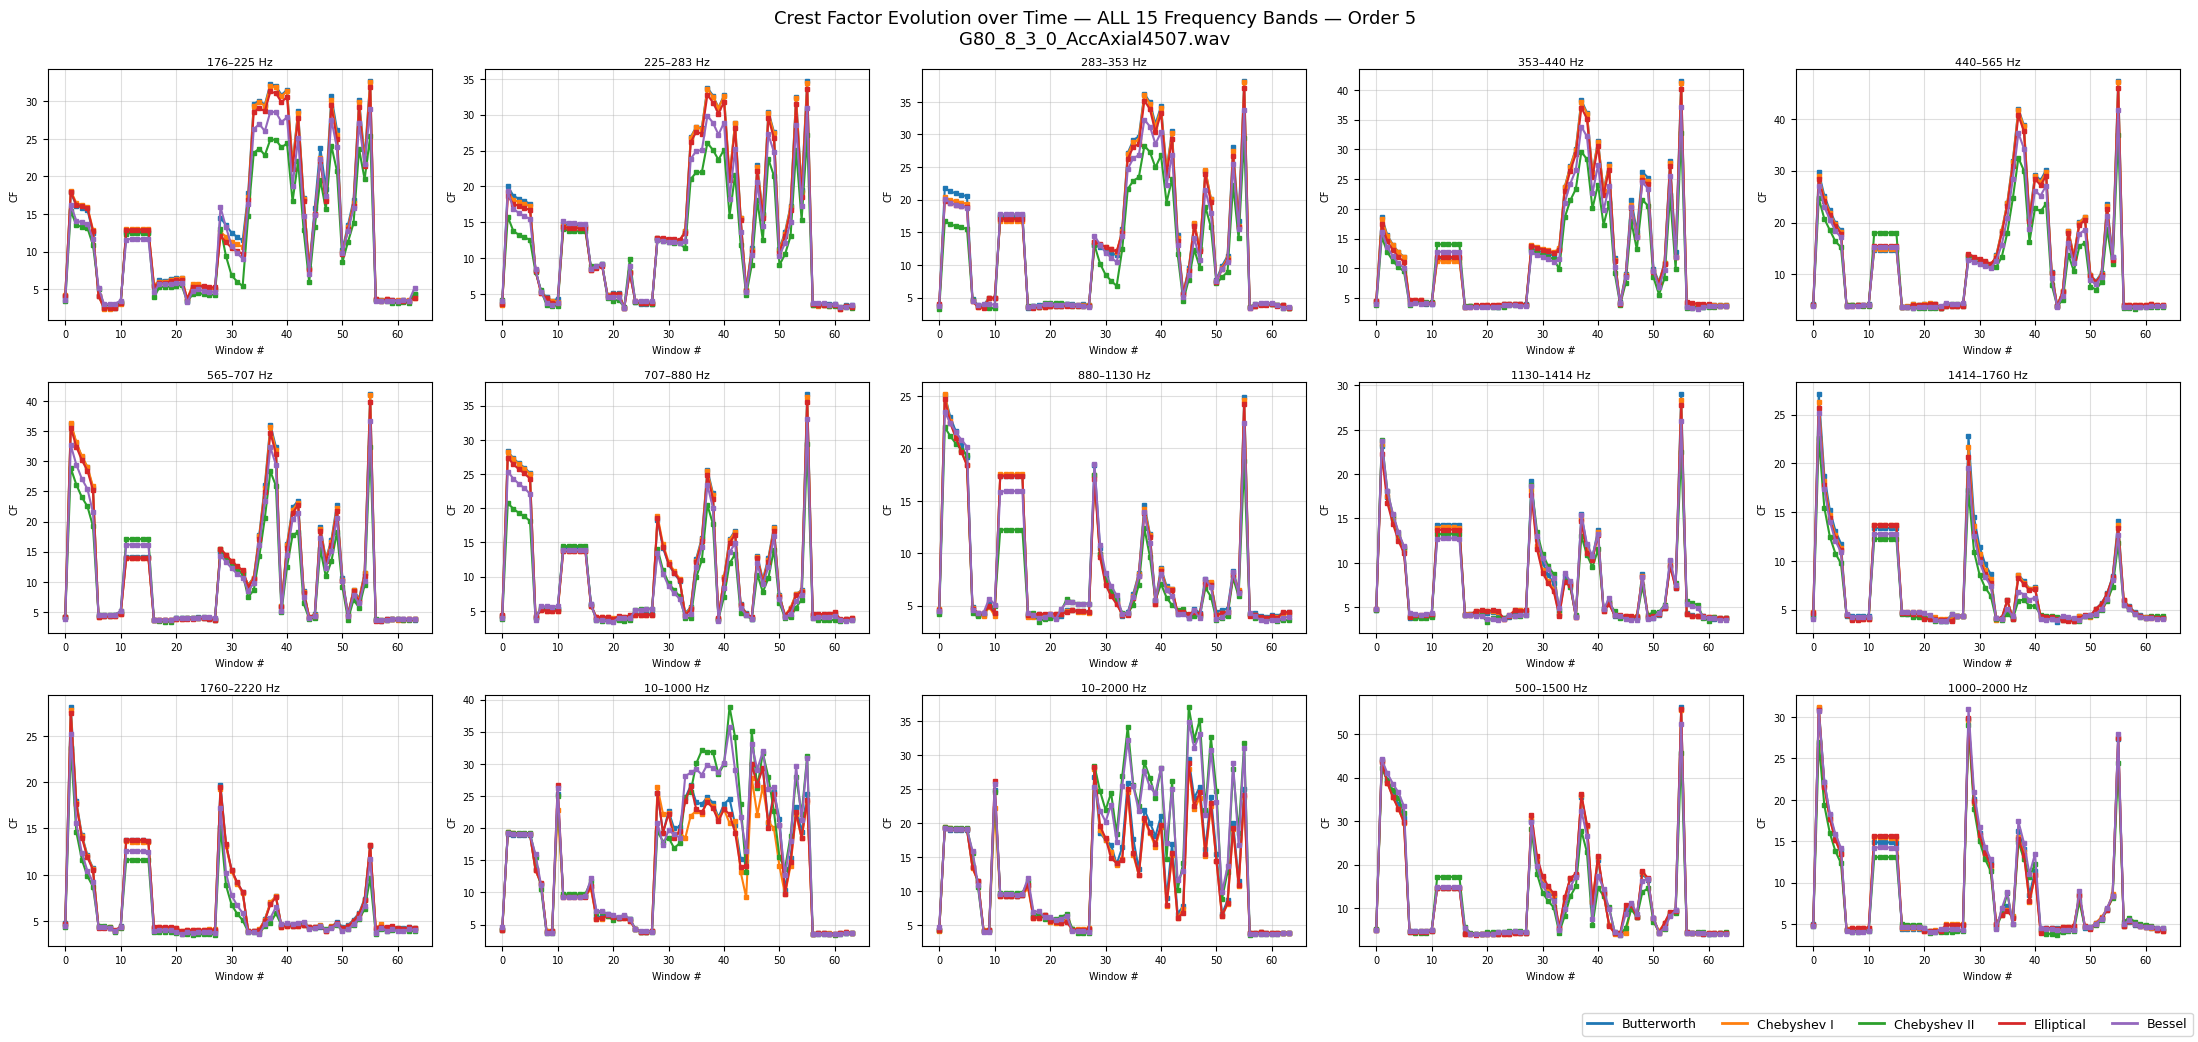

In [18]:
# ── Crest Factor time evolution for ALL 15 frequency bands ────────────────────
# Same grid layout as RMS above — allows direct comparison of CF across bands.

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 3.5), sharey=False)
axes_flat = axes.flatten()

for band_idx in range(N_BANDS):
    ax = axes_flat[band_idx]
    for ftype in FILTER_TYPES:
        sub = df_ref[
            (df_ref.filter_type == ftype) &
            (df_ref.order == FOCUS_ORDER) &
            (df_ref.band_idx == band_idx)
        ].sort_values('window_idx')

        if len(sub) == 0:
            continue
        ax.plot(sub['window_idx'], sub['crest_factor'],
                color=filter_colors[ftype], lw=1.5, marker='s', markersize=3)

    ax.set_title(BAND_LABELS[band_idx], fontsize=8, pad=3)
    ax.set_xlabel('Window #', fontsize=7)
    ax.set_ylabel('CF', fontsize=7)
    ax.tick_params(labelsize=7)

for ax in axes_flat[N_BANDS:]:
    ax.set_visible(False)

fig.legend(handles=handles, loc='lower right', fontsize=9, ncol=5)
fig.suptitle(f'Crest Factor Evolution over Time — ALL {N_BANDS} Frequency Bands — Order {FOCUS_ORDER}\n{ref_name}',
             fontsize=13)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show(); plt.close('all')


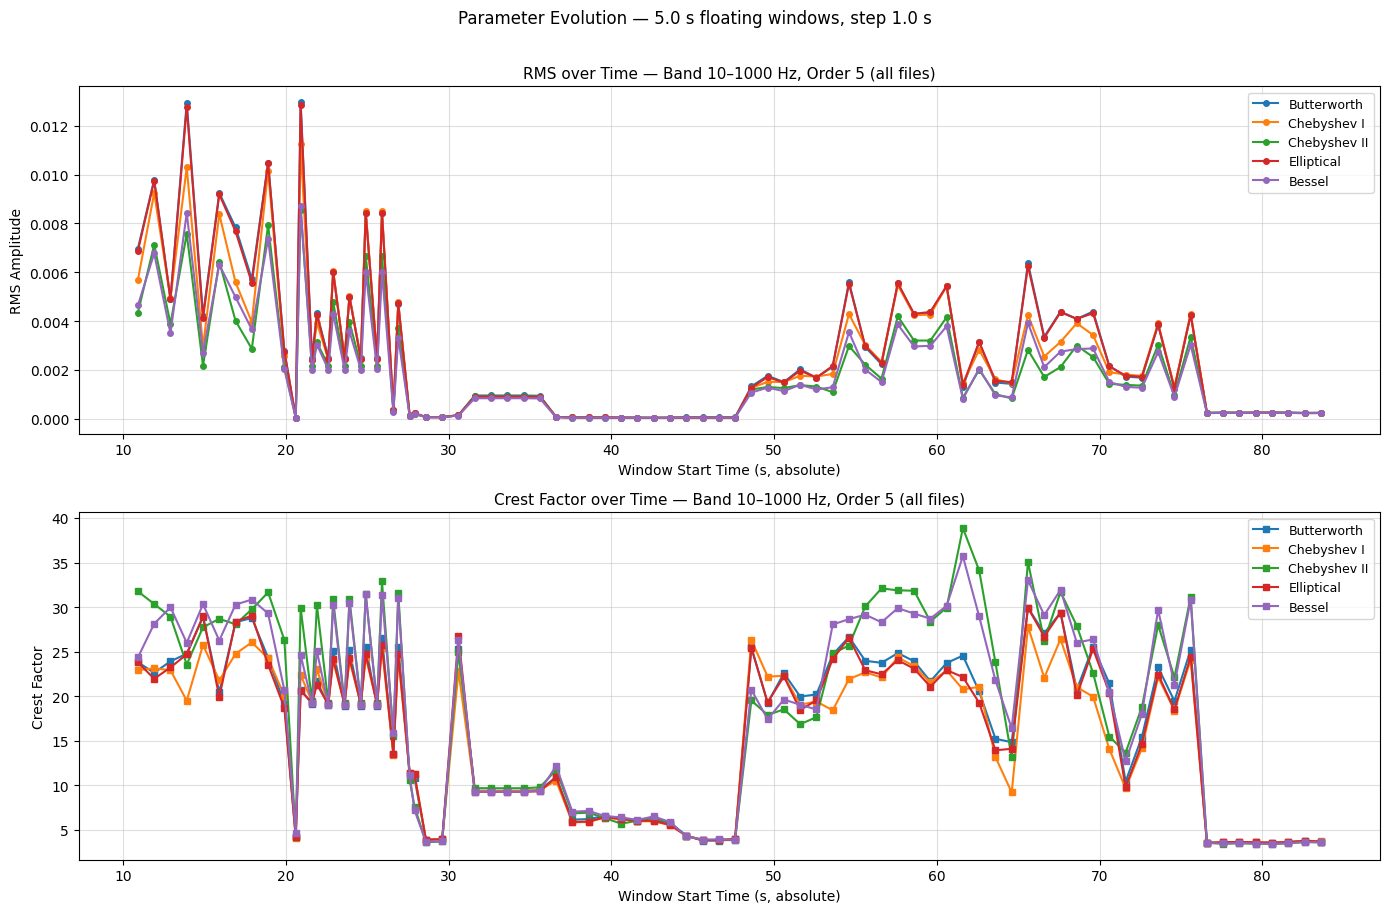

In [19]:
# Parameter evolution for a single broadband band — all filter types on one plot.
# FOCUS_BAND = 11 (10–1000 Hz) chosen as the primary broadband reference band.
FOCUS_BAND  = 11
FOCUS_ORDER = 5

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for ftype in FILTER_TYPES:
    sub = df[
        (df.filter_type == ftype) &
        (df.order == FOCUS_ORDER) &
        (df.band_idx == FOCUS_BAND)
    ].sort_values('window_start_s')

    axes[0].plot(sub['window_start_s'], sub['rms'],
                 marker='o', markersize=4, lw=1.5, label=ftype)
    axes[1].plot(sub['window_start_s'], sub['crest_factor'],
                 marker='s', markersize=4, lw=1.5, label=ftype)

for ax, ylabel, title in zip(
    axes,
    ['RMS Amplitude', 'Crest Factor'],
    [f'RMS over Time — Band {BAND_LABELS[FOCUS_BAND]}, Order {FOCUS_ORDER} (all files)',
     f'Crest Factor over Time — Band {BAND_LABELS[FOCUS_BAND]}, Order {FOCUS_ORDER} (all files)']
):
    ax.set_xlabel('Window Start Time (s, absolute)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle(f'Parameter Evolution — {WINDOW_DURATION_S} s floating windows, step {WINDOW_STEP_S} s',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show(); plt.close('all')


## 7. Complexity and Reliability Comparison

### Computational Complexity

For a filter in SOS form, each biquad (2nd-order section) needs:
- **5 multiplications**: b0, b1, b2, a1, a2
- **4 additions**
- Total: **9 arithmetic operations per output sample per section**

`sosfiltfilt` runs **two passes** (forward + backward) → effective cost = **2 × 9 × n_sections** ops/sample.

### Reliability Metric
**RMS Coefficient of Variation (CV)** = std(RMS) / mean(RMS) across all windows.
Lower CV = more consistent filter output = more reliable.


In [20]:
complexity_rows = []

for ftype, order in product(FILTER_TYPES, FILTER_ORDERS):
    sos = next(
        (filter_cache.get((ftype, order, lo, hi))
         for lo, hi in zip(LOWER_LIMITS, UPPER_LIMITS)
         if filter_cache.get((ftype, order, lo, hi)) is not None),
        None
    )
    if sos is None:
        continue

    cx           = filter_complexity(sos)
    ops_single   = cx['total_operations']
    ops_filtfilt = 2 * ops_single

    avg_time_ms = np.nanmean([
        timing.get((ftype, order, b), np.nan) * 1000.0
        for b in range(N_BANDS)
    ])

    subset   = df[(df.filter_type == ftype) & (df.order == order)]
    rms_mean = subset['rms'].mean()
    rms_cv   = (subset['rms'].std() / rms_mean) if rms_mean > 0 else np.nan

    # Mean per-parameter timing from main loop
    mean_rms_us = subset['rms_time_us'].mean() if 'rms_time_us' in subset.columns else np.nan
    mean_cf_us  = subset['cf_time_us'].mean()  if 'cf_time_us'  in subset.columns else np.nan

    ripple_map = {
        'Butterworth'  : 0.0,
        'Chebyshev I'  : CHEBY1_RIPPLE_DB,
        'Chebyshev II' : 0.0,
        'Elliptical'   : ELLIP_RIPPLE_DB,
        'Bessel'       : 0.0,
    }

    complexity_rows.append({
        'Filter Type'           : ftype,
        'Order'                 : order,
        'SOS Sections'          : cx['n_sections'],
        'Ops/Sample (filtfilt)' : ops_filtfilt,
        'Mean Time/Window (ms)' : round(avg_time_ms, 3),
        'RMS Calc (μs)'         : round(mean_rms_us, 2),
        'CF Calc (μs)'          : round(mean_cf_us, 2),
        'RMS CV'                : round(rms_cv, 4),
        'Passband Ripple (dB)'  : ripple_map[ftype],
    })

df_cx = pd.DataFrame(complexity_rows)
df_cx = df_cx.sort_values(['Order', 'Ops/Sample (filtfilt)']).reset_index(drop=True)

print("=== Computational Complexity, Parameter Timing, and Reliability ===")
print(df_cx.to_string(index=False))


=== Computational Complexity, Parameter Timing, and Reliability ===
 Filter Type  Order  SOS Sections  Ops/Sample (filtfilt)  Mean Time/Window (ms)  RMS Calc (μs)  CF Calc (μs)  RMS CV  Passband Ripple (dB)
 Butterworth      3             3                     54                  6.737         860.11        671.90  1.8068                   0.0
 Chebyshev I      3             3                     54                  6.598         862.04        656.49  1.7981                   0.5
Chebyshev II      3             3                     54                  6.925         921.23        725.06  1.6612                   0.0
  Elliptical      3             3                     54                  7.276         898.37        675.69  1.8018                   0.5
      Bessel      3             3                     54                  7.855         934.83        722.37  1.7995                   0.0
 Butterworth      5             5                     90                  8.545         738.95    

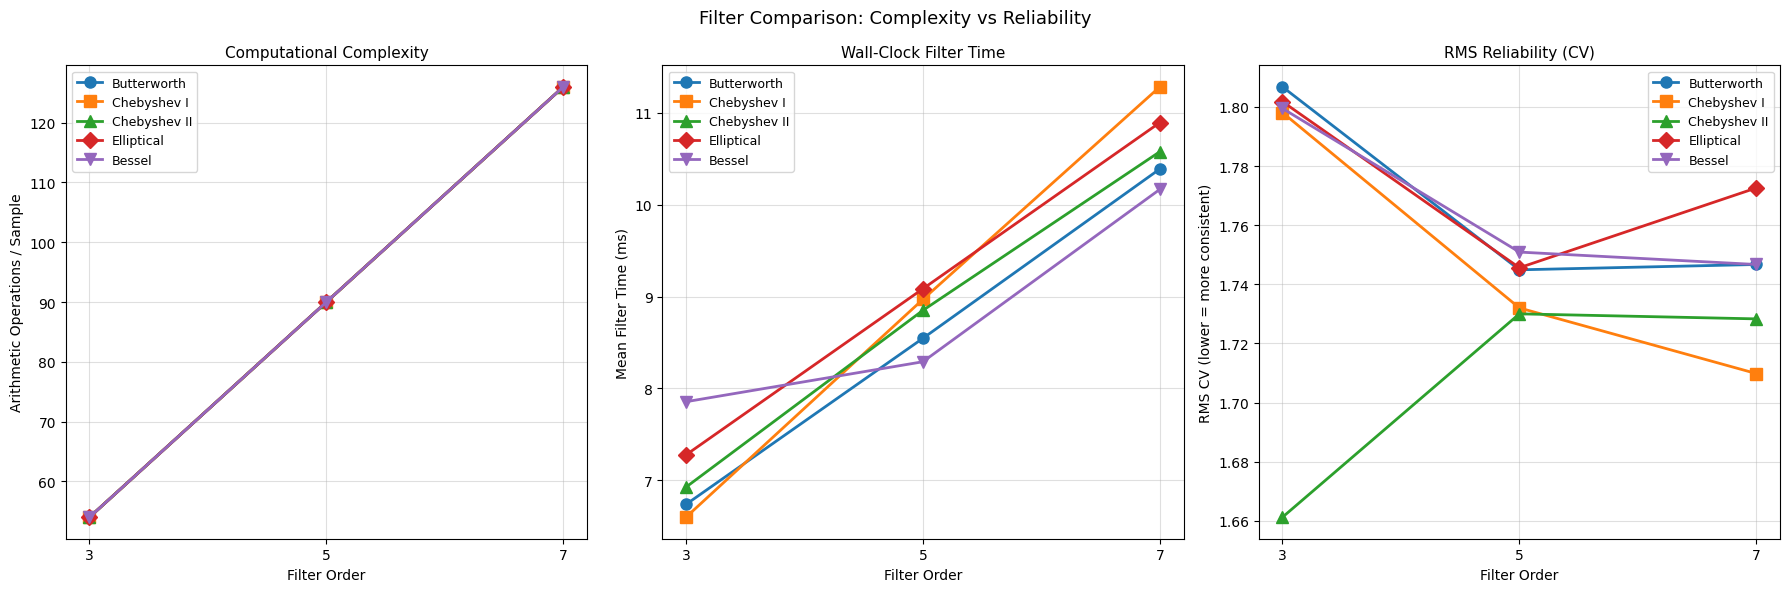

In [21]:
# Three-panel comparison of filter types across orders.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

markers = {'Butterworth': 'o', 'Chebyshev I': 's', 'Chebyshev II': '^',
           'Elliptical': 'D', 'Bessel': 'v'}
colors  = {'Butterworth': '#1f77b4', 'Chebyshev I': '#ff7f0e', 'Chebyshev II': '#2ca02c',
           'Elliptical': '#d62728', 'Bessel': '#9467bd'}

for ftype in FILTER_TYPES:
    sub = df_cx[df_cx['Filter Type'] == ftype].sort_values('Order')
    kw  = dict(marker=markers[ftype], color=colors[ftype], lw=2, markersize=8, label=ftype)

    axes[0].plot(sub['Order'], sub['Ops/Sample (filtfilt)'], **kw)
    axes[1].plot(sub['Order'], sub['Mean Time/Window (ms)'], **kw)
    axes[2].plot(sub['Order'], sub['RMS CV'], **kw)

for ax, ylabel, title in zip(
    axes,
    ['Arithmetic Operations / Sample', 'Mean Filter Time (ms)', 'RMS CV (lower = more consistent)'],
    ['Computational Complexity', 'Wall-Clock Filter Time', 'RMS Reliability (CV)']
):
    ax.set_xlabel('Filter Order')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(FILTER_ORDERS)
    ax.legend(fontsize=9)

fig.suptitle('Filter Comparison: Complexity vs Reliability', fontsize=13)
plt.tight_layout()
plt.show(); plt.close('all')


In [22]:
# ── Export Results to CSV ─────────────────────────────────────────────────────
# Exports all computed parameters, complexity table, and summary for external review.

# 1. Full results table (all windows × files × filter × band)
csv_results = RESULTS_DIR / "blasting_all_results.csv"
df.to_csv(csv_results, index=False, float_format='%.6f')
print(f"Full results   → {csv_results}  ({len(df):,} rows)")

# 2. Per-band averages (mean parameter values per filter × order × band)
df_band_avg = (
    df.groupby(['filename', 'sensor', 'filter_type', 'order', 'band_idx', 'band_label'])[
        ['rms', 'peak', 'crest_factor', 'zcr', 'band_power', 'spectral_centroid',
         'filter_time_ms', 'rms_time_us', 'cf_time_us']
    ].mean()
    .round(6)
    .reset_index()
)
csv_band_avg = RESULTS_DIR / "blasting_band_averages.csv"
df_band_avg.to_csv(csv_band_avg, index=False)
print(f"Band averages  → {csv_band_avg}  ({len(df_band_avg):,} rows)")

# 3. Complexity and reliability table
csv_complexity = RESULTS_DIR / "filter_complexity.csv"
df_cx.to_csv(csv_complexity, index=False)
print(f"Complexity     → {csv_complexity}  ({len(df_cx):,} rows)")

# 4. Per-file summary (one row per file × filter × order)
df_file_summary = (
    df.groupby(['filename', 'sensor', 'filter_type', 'order'])[
        ['rms', 'peak', 'crest_factor', 'zcr', 'band_power', 'spectral_centroid']
    ].agg(['mean', 'std'])
    .round(6)
    .reset_index()
)
df_file_summary.columns = ['_'.join(c).strip('_') for c in df_file_summary.columns]
csv_file_summary = RESULTS_DIR / "blasting_file_summary.csv"
df_file_summary.to_csv(csv_file_summary, index=False)
print(f"File summary   → {csv_file_summary}  ({len(df_file_summary):,} rows)")

print(f"\nAll exports saved to: {RESULTS_DIR}")


Full results   → D:\1 placement\IAESTE INTERNSHIP CZECH\iaeste26-blasting-sound-main\iaeste26-blasting-sound-main\results\blasting_all_results.csv  (18,450 rows)
Band averages  → D:\1 placement\IAESTE INTERNSHIP CZECH\iaeste26-blasting-sound-main\iaeste26-blasting-sound-main\results\blasting_band_averages.csv  (450 rows)
Complexity     → D:\1 placement\IAESTE INTERNSHIP CZECH\iaeste26-blasting-sound-main\iaeste26-blasting-sound-main\results\filter_complexity.csv  (15 rows)
File summary   → D:\1 placement\IAESTE INTERNSHIP CZECH\iaeste26-blasting-sound-main\iaeste26-blasting-sound-main\results\blasting_file_summary.csv  (30 rows)

All exports saved to: D:\1 placement\IAESTE INTERNSHIP CZECH\iaeste26-blasting-sound-main\iaeste26-blasting-sound-main\results


In [23]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print("=" * 80)
print("BLASTING SOUND ANALYSIS — FINAL SUMMARY")
print("=" * 80)

print(f"\nFiles processed : {df['filename'].nunique()}")
for sensor in SENSOR_PRIORITY:
    files = df[df['sensor'] == sensor]['filename'].unique()
    if len(files) > 0:
        print(f"  {sensor:<18}: {len(files)} file(s)")

print(f"\nWindows total   : {df.groupby(['filename','filter_type','order','band_idx']).ngroups:,}")
print(f"Result rows     : {len(df):,}")

print("\n" + "=" * 80)
print("SIGNAL PARAMETERS — Mean values (averaged over all files, bands, orders, windows)")
print("=" * 80)
summary_params = df.groupby('filter_type')[
    ['rms', 'peak', 'crest_factor', 'zcr', 'band_power', 'spectral_centroid']
].mean().round(5)
print(summary_params.to_string())

print("\n" + "=" * 80)
print("TIMING — Mean calculation time per 5-second window (averaged over all bands)")
print("=" * 80)
timing_summary = df.groupby(['filter_type', 'order'])[
    ['filter_time_ms', 'rms_time_us', 'cf_time_us']
].mean().round(3)
print(timing_summary.to_string())

print("\n" + "=" * 80)
print("COMPLEXITY vs RELIABILITY (averaged over orders)")
print("=" * 80)
cx_summary = df_cx.groupby('Filter Type')[
    ['Ops/Sample (filtfilt)', 'Mean Time/Window (ms)', 'RMS CV']
].mean().round(4)
cx_summary.columns = ['Mean Ops/Sample', 'Mean Time (ms)', 'Mean RMS CV']
print(cx_summary.sort_values('Mean Ops/Sample').to_string())

print("\n" + "=" * 80)
print("KEY OBSERVATIONS")
print("=" * 80)
best_cv  = cx_summary['Mean RMS CV'].idxmin()
best_spd = cx_summary['Mean Time (ms)'].idxmin()
print(f"Most consistent (lowest RMS CV) : {best_cv}")
print(f"Fastest filter                  : {best_spd}")
print(f"Steepest rolloff                : Elliptical (equiripple in both passband and stopband)")
print(f"Best phase linearity            : Bessel (constant group delay — best for transients)")
print(f"Recommended for this application: {best_cv} (best balance of speed and consistency)")


BLASTING SOUND ANALYSIS — FINAL SUMMARY

Files processed : 2
  AccAxial4507      : 2 file(s)

Windows total   : 450
Result rows     : 18,450

SIGNAL PARAMETERS — Mean values (averaged over all files, bands, orders, windows)
                  rms     peak  crest_factor        zcr  band_power  spectral_centroid
filter_type                                                                           
Bessel        0.00070  0.01321      13.95172  827.45548         0.0          804.90040
Butterworth   0.00101  0.01765      14.38166  863.65799         0.0          842.03147
Chebyshev I   0.00102  0.01726      14.23885  878.25735         0.0          858.35517
Chebyshev II  0.00070  0.01295      12.65136  806.86160         0.0          790.74501
Elliptical    0.00103  0.01763      14.13735  873.60573         0.0          855.47039

TIMING — Mean calculation time per 5-second window (averaged over all bands)
                    filter_time_ms  rms_time_us  cf_time_us
filter_type  order           